In [36]:
import sys
sys.path.insert(0, 'task')
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from task.task_2_3 import (
    calculate_returns,
    rolling_window_analysis,
    expanding_window_analysis
)

from task.task_4_8 import run_task_4_8

from task.task_9_10 import (
    analyze_portfolio_composition_stability,
    efficient_frontier_dynamics_rolling,
    efficient_frontier_dynamics_expanding,
    efficient_frontier_dynamics_exponential,
    compare_frontier_methods
)

from task.task_13_14_15 import (
    task_13_covariance_from_historical_betas,
    task_14_efficient_frontier_from_betas,
    task_15_efficient_frontier_dynamics_betas,
    compare_covariance_methods,
    load_imoex_data
)

from task.task_16_20 import (
    load_market_index_data,
    calculate_returns as calculate_market_returns,
    prepare_selected_beta_window,
    covariance_from_adjusted_betas,
    efficient_frontier_from_adjusted_betas,
    efficient_frontier_dynamics_adjusted_betas,
    compare_three_methods_on_selected_window,
    compare_three_methods_over_time
)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 100)

import warnings
warnings.filterwarnings('ignore')

### 1. Загрузка и обработка данных

In [37]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    
    df.columns = df.columns.str.strip()
    df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
    df.set_index('date', inplace=True)

    df = df.replace('', np.nan).replace(' ', np.nan) \
            .dropna(how='all') \
            .dropna(axis=1, how='all')
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

In [38]:
def load_prices_data(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path, sep=';', decimal=',')

    return preprocess_data(df)

In [39]:
stoks_prices_df = load_prices_data("data/prices_moex_new.csv")

Информация о данных

In [40]:
print(f"Размер: {stoks_prices_df.shape}")
print(f"Период: {stoks_prices_df.index.min()} - {stoks_prices_df.index.max()}")
print(f"Количество акций: {len(stoks_prices_df.columns)}")
print(f"\nСписок акций: {list(stoks_prices_df.columns)}")

Размер: (2763, 30)
Период: 2015-01-05 00:00:00 - 2025-12-30 00:00:00
Количество акций: 30

Список акций: ['SBER', 'SBERP', 'GAZP', 'LKOH', 'ROSN', 'NVTK', 'TATN', 'TATNP', 'SNGS', 'SNGSP', 'GMKN', 'CHMF', 'NLMK', 'MAGN', 'MTSS', 'AFLT', 'VTBR', 'MOEX', 'PLZL', 'ALRS', 'MGNT', 'PHOR', 'AKRN', 'FEES', 'HYDR', 'IRAO', 'BSPB', 'TRNFP', 'SIBN', 'LSRG']


### Доходности

In [41]:
returns = calculate_returns(stoks_prices_df)

Визуализация кумулятивных доходностей для первых 5 акций

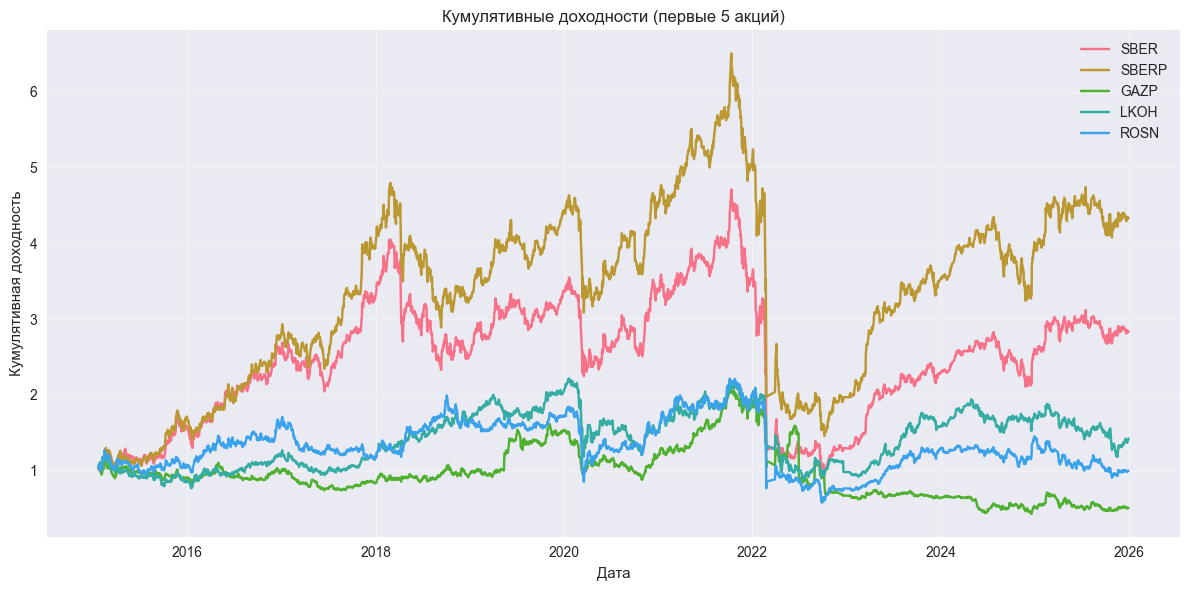

In [42]:
plt.figure(figsize=(12, 6))
for col in returns.columns[:5]:
    cumulative_returns = (1 + returns[col]).cumprod()
    plt.plot(returns.index, cumulative_returns, label=col)

plt.title('Кумулятивные доходности (первые 5 акций)')
plt.xlabel('Дата')
plt.ylabel('Кумулятивная доходность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Векторы доходностей и ковариационные матрицы на различные даты

#### 2.a Скользящее окно

In [43]:
rolling_results = rolling_window_analysis(returns, window_size='1Y', step_size='1Y')

In [44]:
print(f"\nПолучено окон: {len(rolling_results)}")

if rolling_results:
    first_date = list(rolling_results.keys())[0]
    first_result = rolling_results[first_date]
    
    print(f"\n--- Первое окно ---")
    print(f"Период: {first_result['window_start'].strftime('%Y-%m-%d')} - {first_date.strftime('%Y-%m-%d')}")
    print(f"Размер окна: {len(first_result['window_returns'])} наблюдений")
    print(f"Размер ковариационной матрицы: {first_result['covariance_matrix'].shape}")
    
    # Проверка ковариационной матрицы
    cov_matrix = first_result['covariance_matrix']
    print(f"\nСвойства ковариационной матрицы:")
    print(f"- Симметричность: {np.allclose(cov_matrix, cov_matrix.T)}")
    print(f"- Определитель: {np.linalg.det(cov_matrix):.6e}")


Получено окон: 10

--- Первое окно ---
Период: 2015-01-21 - 2016-01-21
Размер окна: 251 наблюдений
Размер ковариационной матрицы: (30, 30)

Свойства ковариационной матрицы:
- Симметричность: True
- Определитель: 2.870323e-106


Визуализация динамики средних доходностей во времени

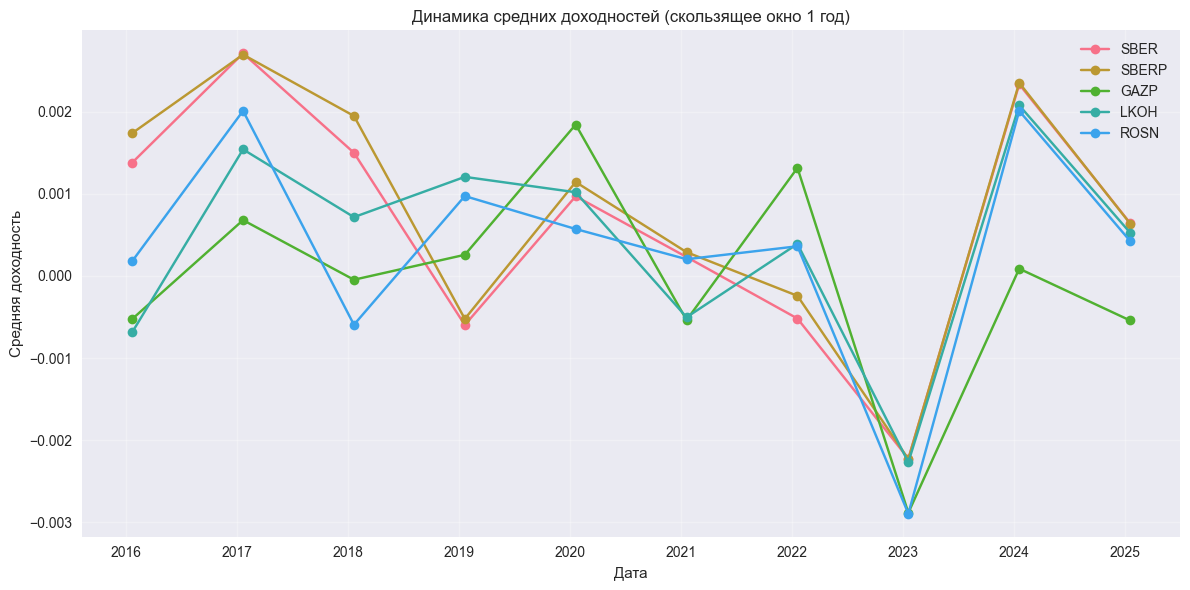

In [45]:
if rolling_results:
    dates = list(rolling_results.keys())
    mean_returns_history = [rolling_results[date]['mean_returns'] for date in dates]
    mean_returns_df = pd.DataFrame(mean_returns_history, index=dates, columns=returns.columns)
    
    plt.figure(figsize=(12, 6))
    for col in returns.columns[:5]:
        plt.plot(mean_returns_df.index, mean_returns_df[col], marker='o', label=col)
    
    plt.title('Динамика средних доходностей (скользящее окно 1 год)')
    plt.xlabel('Дата')
    plt.ylabel('Средняя доходность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Выводы**:
- Определитель матрицы очень мал (~2.87e-106), что характерно для 30x30 матрицы с сильной корреляцией активов
- Средние доходности не стабильны во времени - это демонстрирует, что историческая доходность — ненадежный прогноз будущего

#### 2.b Расширяющее окно

In [46]:
expanding_results = expanding_window_analysis(returns, step_size='1Y')

In [47]:
print(f"\nПолучено окон: {len(expanding_results)}")

if expanding_results:
    print("\n--- Динамика размера окна ---")
    for i, (date, result) in enumerate(list(expanding_results.items())[:5]):
        print(f"Окно {i+1}:  {date.strftime('%Y-%m-%d')} - {result['window_size']} наблюдений")
    print("...")
    
    last_date = list(expanding_results.keys())[-1]
    last_result = expanding_results[last_date]
    print(f"Окно {len(expanding_results)}: {last_date.strftime('%Y-%m-%d')} - {last_result['window_size']} наблюдений")


Получено окон: 10

--- Динамика размера окна ---
Окно 1:  2016-01-21 - 251 наблюдений
Окно 2:  2017-01-20 - 505 наблюдений
Окно 3:  2018-01-20 - 755 наблюдений
Окно 4:  2019-01-20 - 1008 наблюдений
Окно 5:  2020-01-20 - 1260 наблюдений
...
Окно 10: 2025-01-18 - 2475 наблюдений


Сравнение скользящего и расширяющегося окон

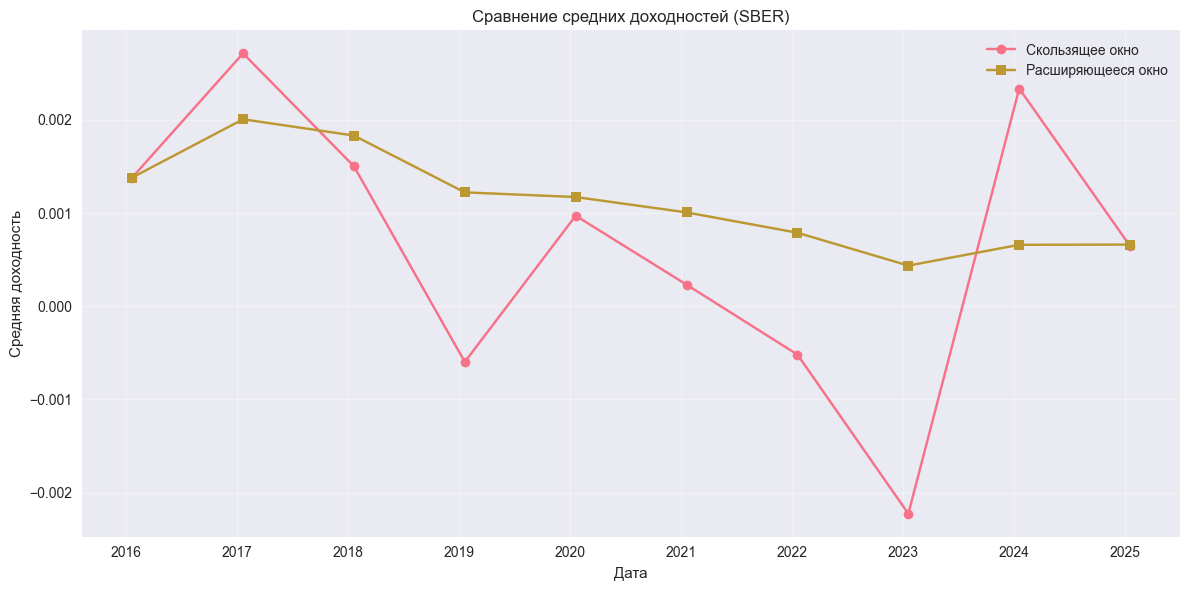

In [48]:
if rolling_results and expanding_results:
    rolling_dates = list(rolling_results.keys())
    expanding_dates = list(expanding_results.keys())
    
    ticker = returns.columns[0]
    
    rolling_means = [rolling_results[date]['mean_returns'][0] for date in rolling_dates]
    expanding_means = [expanding_results[date]['mean_returns'][0] for date in expanding_dates]
    
    plt.figure(figsize=(12, 6))
    plt.plot(rolling_dates, rolling_means, marker='o', label='Скользящее окно')
    plt.plot(expanding_dates, expanding_means, marker='s', label='Расширяющееся окно')
    plt.title(f'Сравнение средних доходностей ({ticker})')
    plt.xlabel('Дата')
    plt.ylabel('Средняя доходность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Выводы**:
- Скользящее окно реагирует быстрее на изменения рыночной ситуации (использует только свежие данные)
- Расширяющееся окно более стабильно (учитывает всю историю), но может отставать от текущих трендов
- Для краткосрочных прогнозов скользящее окно может быть предпочтительнее
- Для долгосрочных оценок — расширяющееся окно

### 3. Экспоненциальное забывание

- Скользящее окно (1 год)
- lambda=0.94

In [49]:
rolling_exp_results = rolling_window_analysis(
    returns, window_size='1Y', step_size='1Y', lambda_param=0.94
)

Сравнение обычного и экспоненциального взвешивания

Получено окон: 10


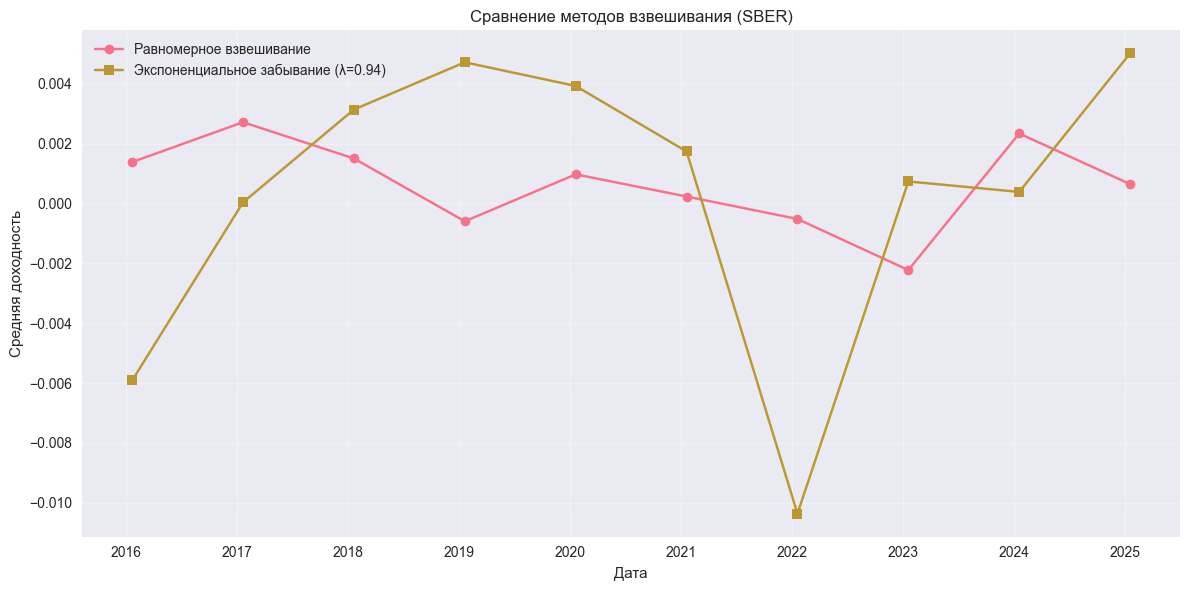


--- Численное сравнение для первой даты ---
Дата: 2016-01-21
Равномерное взвешивание: 0.001382
Экспоненциальное забывание: -0.005912
Разница: -0.007294


In [50]:
print(f"Получено окон: {len(rolling_exp_results)}")

if rolling_results and rolling_exp_results:
    ticker = returns.columns[0]
    ticker_idx = 0
    
    dates = list(rolling_results.keys())
    rolling_means = [rolling_results[date]['mean_returns'][ticker_idx] for date in dates]
    exp_means = [rolling_exp_results[date]['mean_returns'][ticker_idx] for date in dates]
    
    plt.figure(figsize=(12, 6))
    plt.plot(dates, rolling_means, marker='o', label='Равномерное взвешивание')
    plt.plot(dates, exp_means, marker='s', label='Экспоненциальное забывание (λ=0.94)')
    plt.title(f'Сравнение методов взвешивания ({ticker})')
    plt.xlabel('Дата')
    plt.ylabel('Средняя доходность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n--- Численное сравнение для первой даты ---")
    first_date = dates[0]
    print(f"Дата: {first_date.strftime('%Y-%m-%d')}")
    print(f"Равномерное взвешивание: {rolling_means[0]:.6f}")
    print(f"Экспоненциальное забывание: {exp_means[0]:.6f}")
    print(f"Разница: {exp_means[0] - rolling_means[0]:.6f}")

**Выводы:**
- Экспоненциальное забывание дает оценки, отличные от равномерного взвешивания
- Различия зависят от конкретной даты и динамики цен
- В периоды стабильности различия могут быть минимальными
- В периоды сильных изменений экспоненциальное забывание быстрее адаптируется

### Общие выводы по блоку
1) Нестабильность оценок: Доходности и риски акций значительно меняются во времени, поэтому статичные оценки могут быть ошибочными
2) Выбор метода взвешивания:
    - Для краткосрочных прогнозов: экспоненциальное забывание или скользящее окно
    - Для долгосрочных стратегий: расширяющееся окно
3) Важность регулярного пересчета: Портфельные веса нужно обновлять с использованием свежих данных
4) Диверсификация: Различия в динамике акций подтверждают важность диверсификации для снижения риска

### 4. Анализ влияния ограничений в optimizer на границу эффективных портфелей

В этом разделе выполняются пункты 4-8.  
Мы берем один выбранный исторический подход из предыдущего блока и используем его как вход для optimizer.

**Выбор для пункта 4:**
- скользящее окно длиной 1 год,
- шаг 1 год,
- экспоненциальное забывание с `lambda = 0.94`,
- реально последнее доступное окно по последней дате выборки.

#### 4.1. Запуск расчета для пунктов 4-8

In [51]:
results_4_8 = run_task_4_8(
    returns=returns,
    asset_names=list(returns.columns),
    window_method='rolling',
    window_size='1Y',
    step_size='1Y',
    lambda_param=0.94,
    n_points=12,
    selection_mode='latest'
)

selected_window = results_4_8['selected_window']

print("Выбранное окно и схема взвешивания:")
print(f"Метод окна: {selected_window['window_method']}")
print(f"Размер окна: {selected_window['window_size']}")
print(f"Шаг окна: {selected_window['step_size']}")
print(f"Режим выбора окна: {selected_window['selection_mode']}")
print(f"Lambda: {selected_window['lambda_param']}")
print(f"Начало окна: {selected_window['window_start']}")
print(f"Конец окна: {selected_window['window_end']}")
print(f"Число наблюдений: {selected_window['window_n_obs']}")


Выбранное окно и схема взвешивания:
Метод окна: rolling
Размер окна: 1Y
Шаг окна: 1Y
Режим выбора окна: latest
Lambda: 0.94
Начало окна: 2025-01-03 00:00:00
Конец окна: 2025-12-30 00:00:00
Число наблюдений: 250


#### 4.2. Таблица сравнения сценариев

Основные характеристики четырех сценариев:
- число рассчитанных точек на границе,
- доходность и риск GMV-портфеля,
- диапазоны риск-доходность на границе,
- тип построения границы (`bounded_upper_branch` или `visual_fragment_of_unbounded_frontier`).



In [52]:
comparison_4_8 = results_4_8['comparison']
comparison_4_8

,scenario,frontier_mode,n_frontier_points,gmv_return,gmv_volatility,frontier_min_return,frontier_max_return,frontier_min_volatility,frontier_max_volatility
0,Пункт 5 - short allowed without limits,visual_fragment_of_unbounded_frontier,12,-0.095351,0.046825,-0.095351,3.079419,0.046825,0.163887
1,"Пункт 6 - short allowed, but each weight >= -25%",bounded_upper_branch,12,-0.130808,0.047540,-0.130808,9.311345,0.047540,1.718418
2,Пункт 7 - no short selling,bounded_upper_branch,12,-0.015747,0.107651,-0.015747,1.256831,0.107651,0.290119
3,Пункт 8 - each asset weight >= 2%,bounded_upper_branch,12,0.112191,0.140011,0.112191,0.612470,0.140011,0.206583


#### 4.3. График эффективных границ

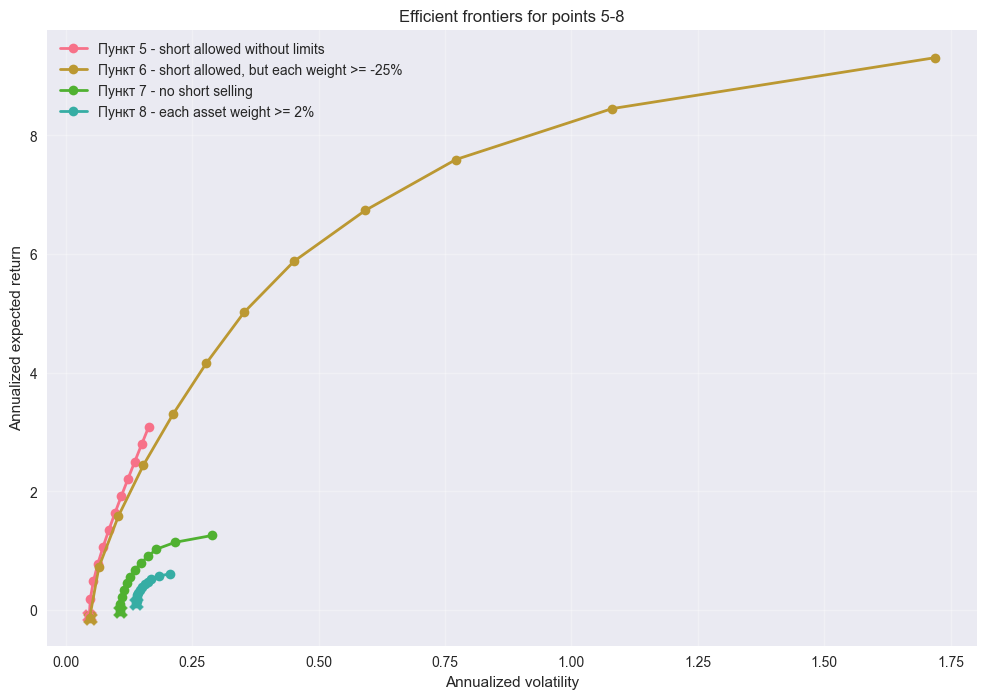

In [53]:
frontiers_4_8 = results_4_8['frontiers']
summaries_4_8 = results_4_8['summaries']

plt.figure(figsize=(12, 8))

for scenario_name, frontier_df in frontiers_4_8.items():
    plt.plot(
        frontier_df['portfolio_volatility'],
        frontier_df['portfolio_return'],
        marker='o',
        linewidth=2,
        label=scenario_name
    )

    gmv = summaries_4_8[scenario_name]
    plt.scatter(
        gmv['volatility'],
        gmv['return'],
        s=100,
        marker='X'
    )

plt.xlabel('Annualized volatility')
plt.ylabel('Annualized expected return')
plt.title('Efficient frontiers for points 5-8')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 4.4. Структура GMV-портфелей

In [54]:
for scenario_name, summary in summaries_4_8.items():
    print('=' * 80)
    print(f'Сценарий: {scenario_name}')
    print(f"GMV return: {summary['return']:.4f}")
    print(f"GMV volatility: {summary['volatility']:.4f}")
    print('Top-10 weights in GMV portfolio:')
    print(summary['weights'].head(10))
    print()

Сценарий: Пункт 5 - short allowed without limits
GMV return: -0.0954
GMV volatility: 0.0468
Top-10 weights in GMV portfolio:
SBERP    1.232360
AKRN     0.407890
CHMF     0.149221
SIBN     0.144895
TATNP    0.139940
MTSS     0.119794
ROSN     0.082959
PHOR     0.079056
BSPB     0.073451
IRAO     0.064006
dtype: float64

Сценарий: Пункт 6 - short allowed, but each weight >= -25%
GMV return: -0.1308
GMV volatility: 0.0475
Top-10 weights in GMV portfolio:
SBERP    0.892130
AKRN     0.388161
SIBN     0.159493
MTSS     0.154654
CHMF     0.118143
MAGN     0.091610
PHOR     0.079595
LSRG     0.073780
IRAO     0.072621
TATNP    0.062783
dtype: float64

Сценарий: Пункт 7 - no short selling
GMV return: -0.0157
GMV volatility: 0.1077
Top-10 weights in GMV portfolio:
AKRN     2.965112e-01
SBERP    2.931709e-01
BSPB     1.137750e-01
SNGSP    8.812304e-02
PHOR     7.802009e-02
LSRG     7.722351e-02
MTSS     3.990072e-02
FEES     1.327562e-02
TRNFP    3.064879e-17
ROSN     2.742236e-17
dtype: float64


#### 4.5. ИТОГО

при unrestricted short optimizer имеет максимум свободы, поэтому граница обычно наиболее гибкая;
при short limit 25% возможности хеджирования уменьшаются;
при no short портфель становится более ограниченным и часто более концентрированным;
при minimum 2% in each asset возникает вынужденная диверсификация, потому что optimizer обязан держать все акции хотя бы в малой доле.

### Анализ стабильности во времени границы эффективных портфелей

#### 9. Динамика изменения границы эффективных портфелей

##### 9.а Скользящее окно
- Окно: 1 год
- Шаг: 1 год

In [55]:
rolling_frontiers, rolling_stability = efficient_frontier_dynamics_rolling(
    returns, window_size='1Y', step_size='1Y', n_points=50
)

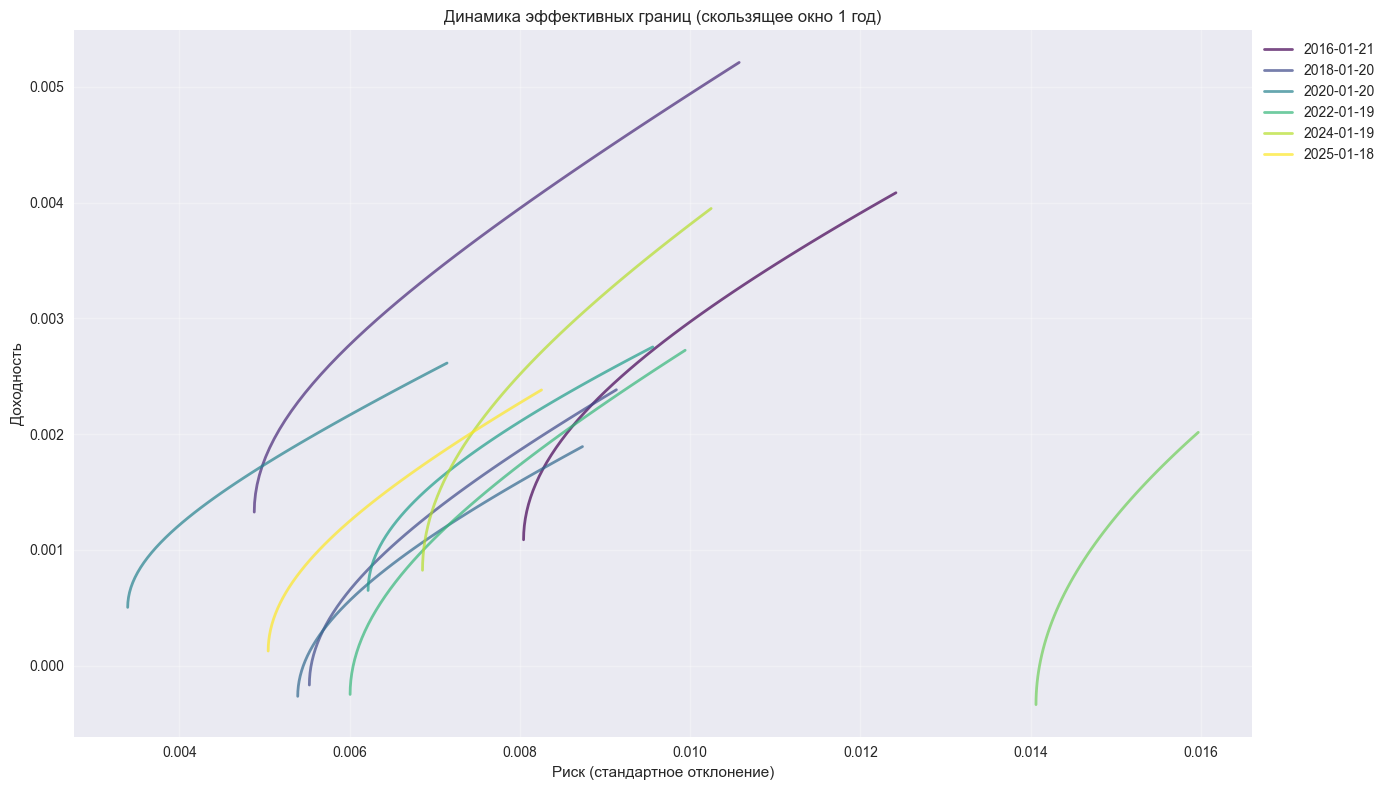

In [56]:
# Визуализация эффективных границ для всех окон
plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(rolling_frontiers)))

for i, (date, frontier) in enumerate(sorted(rolling_frontiers.items())):
    label = date.strftime('%Y-%m-%d') if i % 2 == 0 or i == len(rolling_frontiers) - 1 else None
    plt.plot(frontier['stds'], frontier['returns'], 
             color=colors[i], linewidth=2, alpha=0.7, label=label)

plt.xlabel('Риск (стандартное отклонение)')
plt.ylabel('Доходность')
plt.title('Динамика эффективных границ (скользящее окно 1 год)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

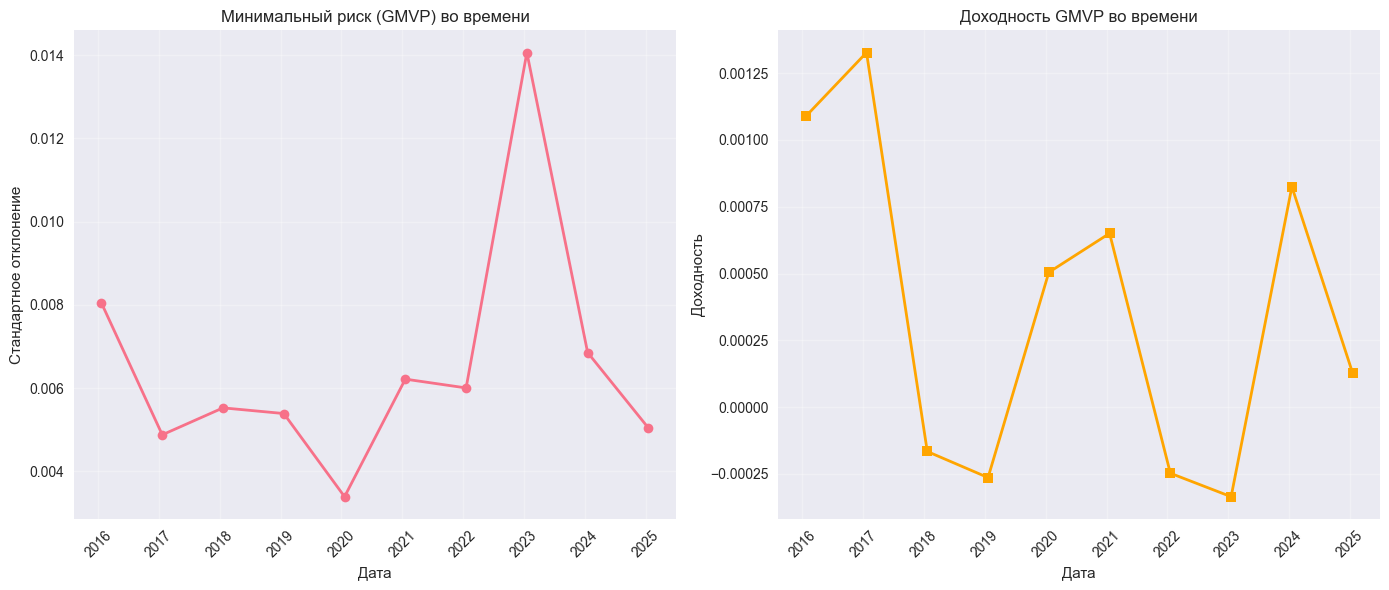

In [57]:
# График динамики минимального риска во времени
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(rolling_stability.index, rolling_stability['min_std'], marker='o', linewidth=2)
plt.title('Минимальный риск (GMVP) во времени')
plt.xlabel('Дата')
plt.ylabel('Стандартное отклонение')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(rolling_stability.index, rolling_stability['min_std_return'], marker='s', linewidth=2, color='orange')
plt.title('Доходность GMVP во времени')
plt.xlabel('Дата')
plt.ylabel('Доходность')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

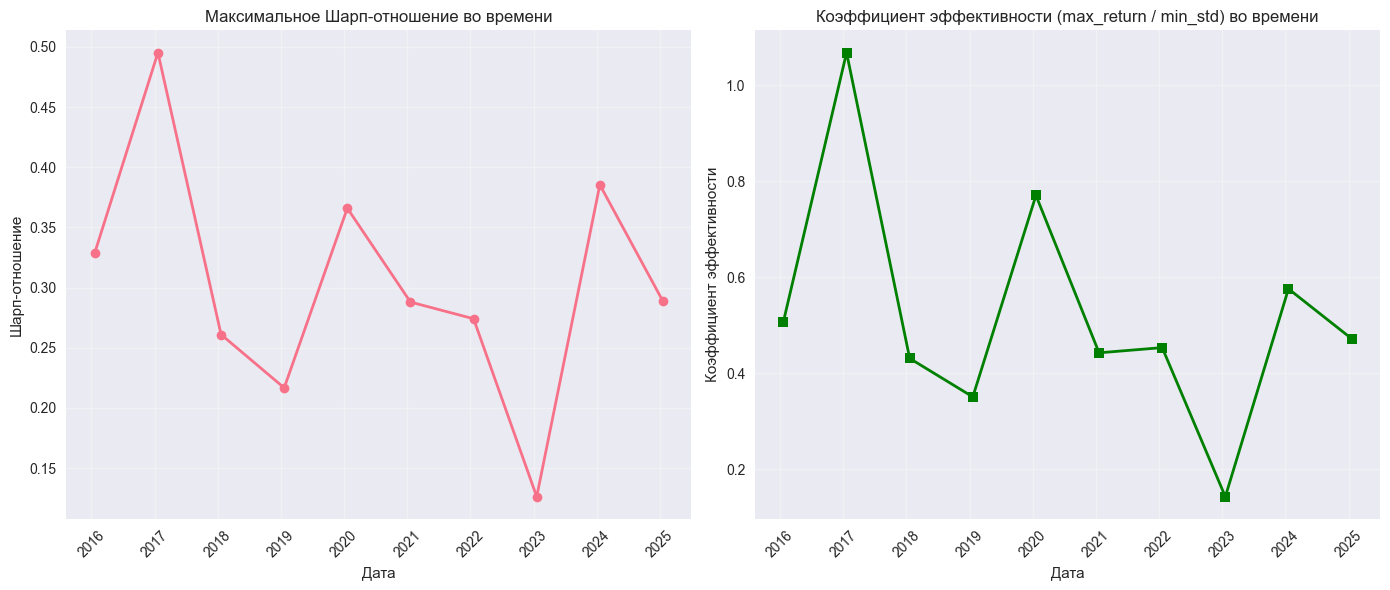

In [58]:
# График динамики максимального Шарпа во времени
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(rolling_stability.index, rolling_stability['max_sharpe'], marker='o', linewidth=2)
plt.title('Максимальное Шарп-отношение во времени')
plt.xlabel('Дата')
plt.ylabel('Шарп-отношение')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(rolling_stability.index, rolling_stability['efficiency_ratio'], marker='s', linewidth=2, color='green')
plt.title('Коэффициент эффективности (max_return / min_std) во времени')
plt.xlabel('Дата')
plt.ylabel('Коэффициент эффективности')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 9.b Расширяющееся окно

In [59]:
expanding_frontiers, expanding_stability = efficient_frontier_dynamics_expanding(
    returns, step_size='1Y', n_points=50
)

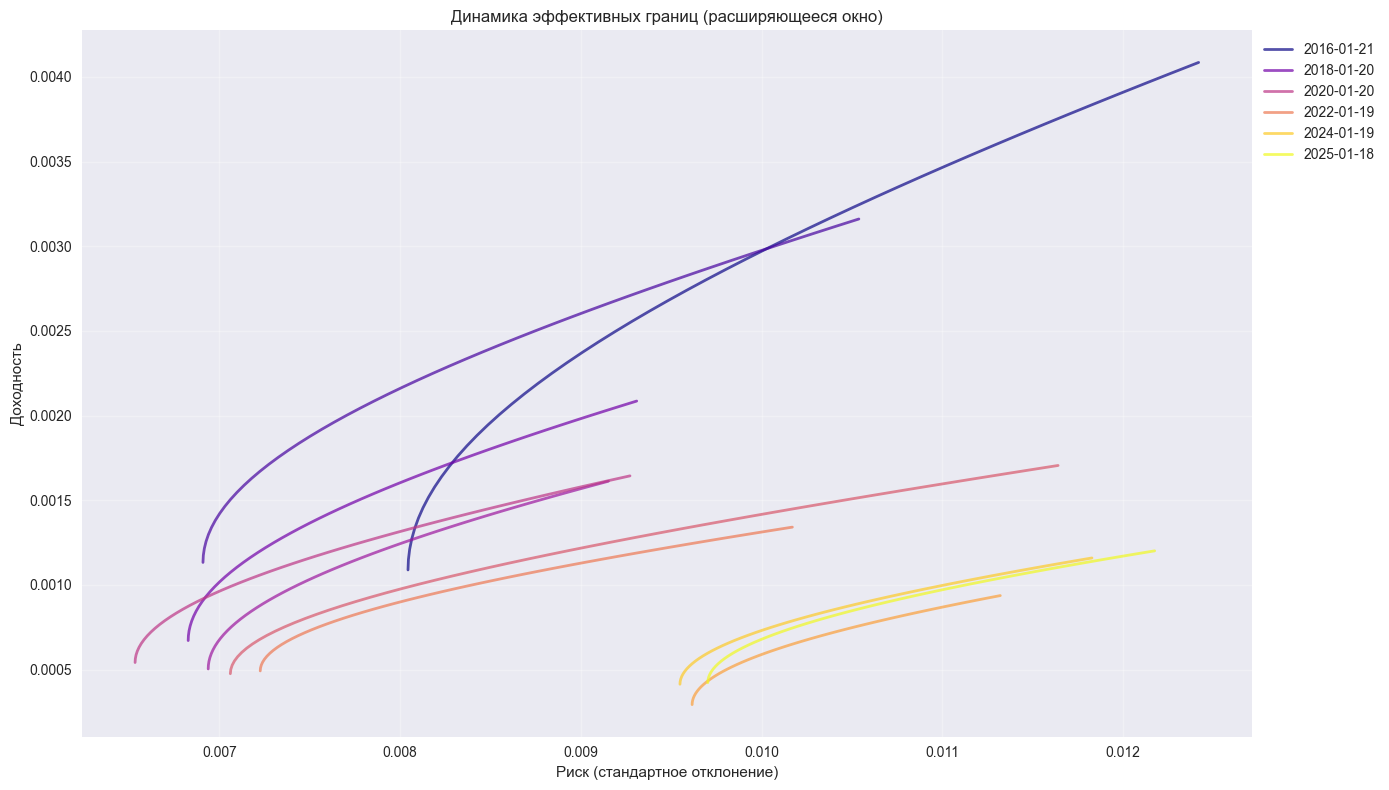

In [60]:
plt.figure(figsize=(14, 8))
colors = plt.cm.plasma(np.linspace(0, 1, len(expanding_frontiers)))

for i, (date, frontier) in enumerate(sorted(expanding_frontiers.items())):
    label = date.strftime('%Y-%m-%d') if i % 2 == 0 or i == len(expanding_frontiers) - 1 else None
    plt.plot(frontier['stds'], frontier['returns'], 
             color=colors[i], linewidth=2, alpha=0.7, label=label)

plt.xlabel('Риск (стандартное отклонение)')
plt.ylabel('Доходность')
plt.title('Динамика эффективных границ (расширяющееся окно)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 10 Экспоненциальное забывание (скользящее окно)

In [61]:
rolling_exp_frontiers, rolling_exp_stability = efficient_frontier_dynamics_exponential(
    returns, window_size='1Y', step_size='1Y', lambda_param=0.94, n_points=50
)

print(f"\nПолучено окон: {len(rolling_exp_frontiers)}")


Получено окон: 10


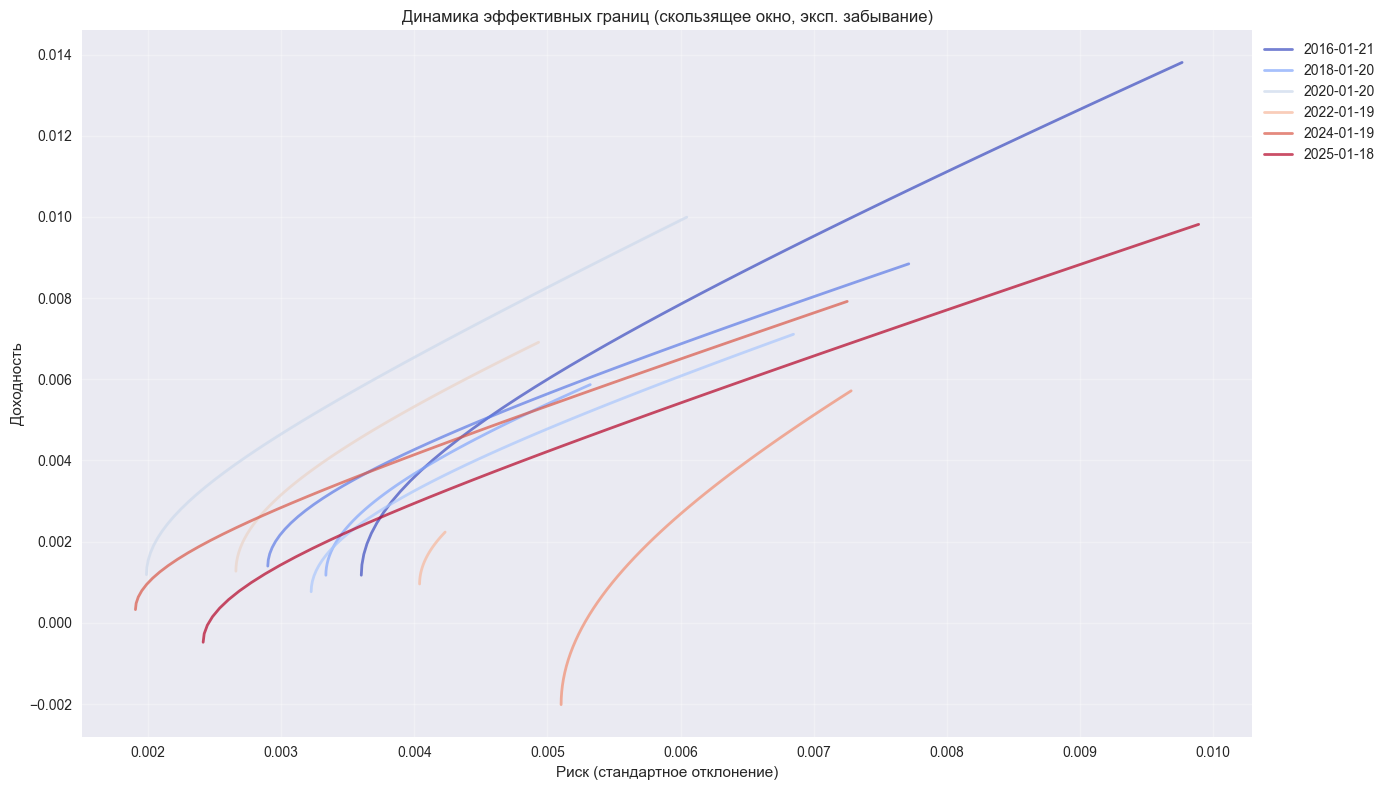

In [62]:
plt.figure(figsize=(14, 8))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(rolling_exp_frontiers)))

for i, (date, frontier) in enumerate(sorted(rolling_exp_frontiers.items())):
    label = date.strftime('%Y-%m-%d') if i % 2 == 0 or i == len(rolling_exp_frontiers) - 1 else None
    plt.plot(frontier['stds'], frontier['returns'], 
             color=colors[i], linewidth=2, alpha=0.7, label=label)

plt.xlabel('Риск (стандартное отклонение)')
plt.ylabel('Доходность')
plt.title('Динамика эффективных границ (скользящее окно, эксп. забывание)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Сравнение методов

In [63]:
comparison = compare_frontier_methods([
    ('Скользящее окно', rolling_frontiers),
    ('Расширяющееся окно', expanding_frontiers),
    ('Скользящее окно (эксп. забывание)', rolling_exp_frontiers)
])

Минимальный риск по методам

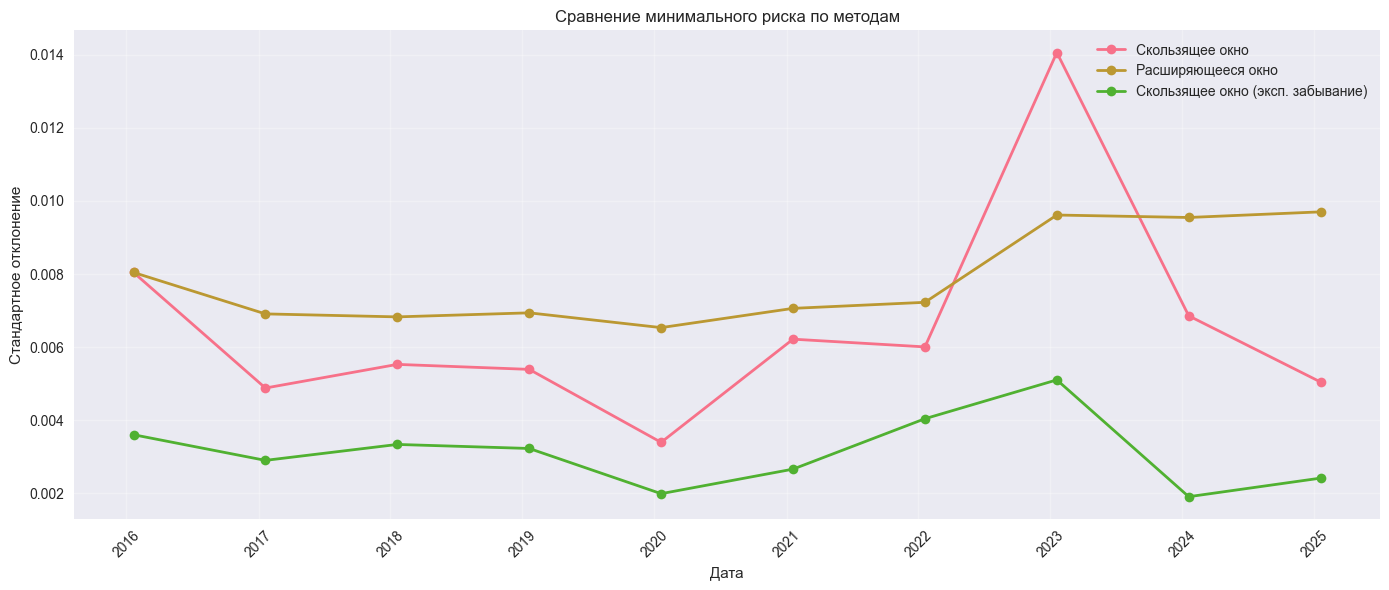

In [64]:
plt.figure(figsize=(14, 6))

for method in comparison.index.get_level_values(0).unique():
    data = comparison.loc[method]
    plt.plot(data.index, data['min_std'], marker='o', linewidth=2, label=method)

plt.title('Сравнение минимального риска по методам')
plt.xlabel('Дата')
plt.ylabel('Стандартное отклонение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Максимальный Шарп по методам

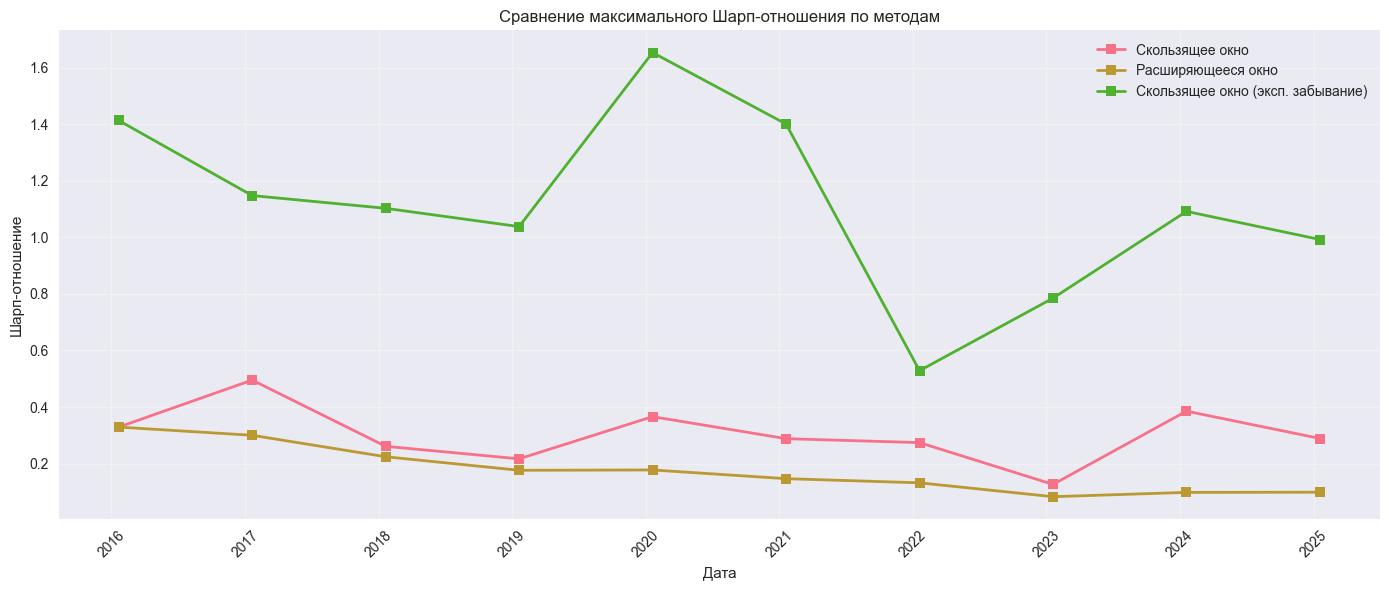

In [65]:
plt.figure(figsize=(14, 6))

for method in comparison.index.get_level_values(0).unique():
    data = comparison.loc[method]
    plt.plot(data.index, data['max_sharpe'], marker='s', linewidth=2, label=method)

plt.title('Сравнение максимального Шарп-отношения по методам')
plt.xlabel('Дата')
plt.ylabel('Шарп-отношение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Анализ стабильности состава портфелей

In [66]:
portfolio_stability = analyze_portfolio_composition_stability(
    rolling_frontiers, returns.columns, percentile=50
)

Динамика весов для первых 5 акций

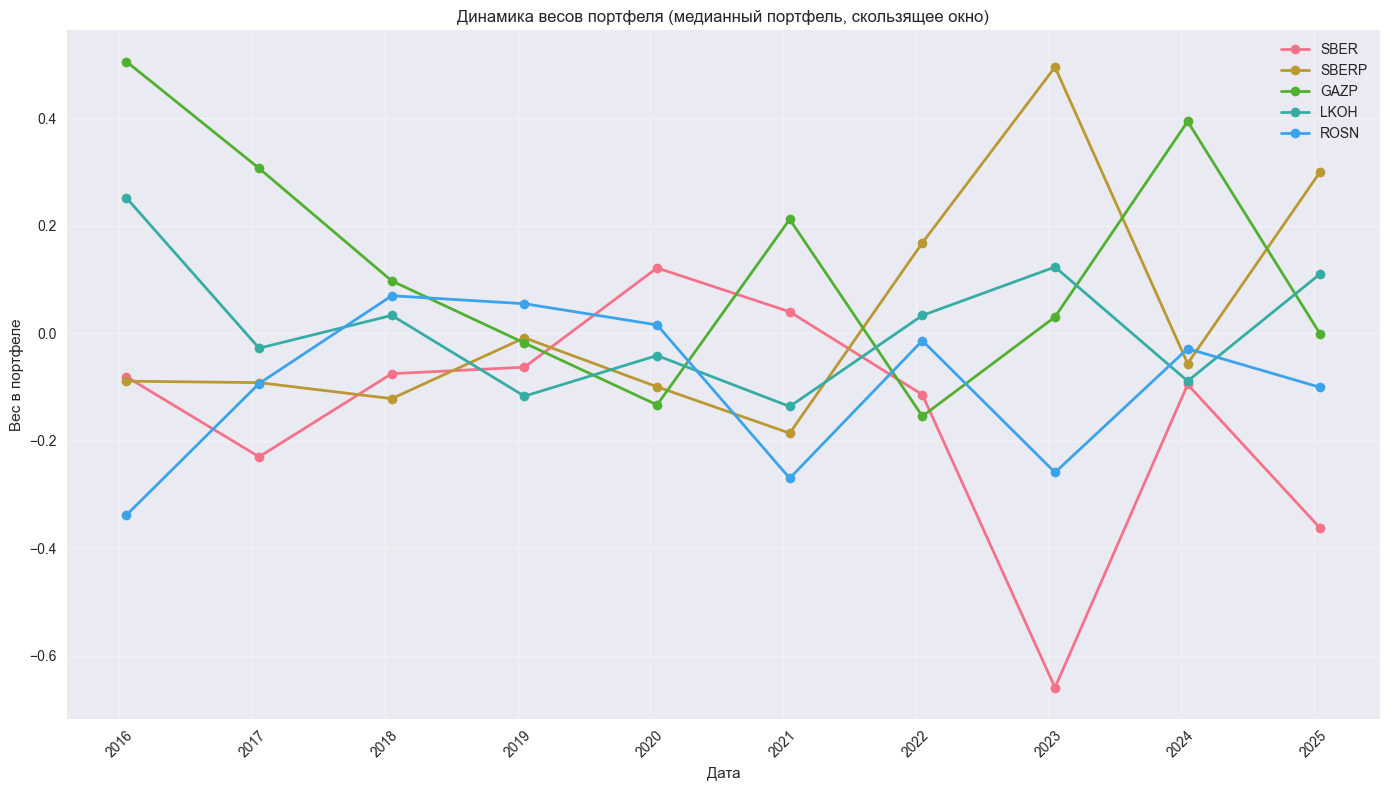

In [67]:
plt.figure(figsize=(14, 8))

for i, ticker in enumerate(returns.columns[:5]):
    plt.plot(portfolio_stability.index, portfolio_stability[f'w_{ticker}'], 
             marker='o', linewidth=2, label=ticker)

plt.title('Динамика весов портфеля (медианный портфель, скользящее окно)')
plt.xlabel('Дата')
plt.ylabel('Вес в портфеле')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Итоговый анализ

In [68]:
print("=== Итоговый анализ ===")
print(f"\nПериод данных: {returns.index.min()} - {returns.index.max()}")
print(f"Всего наблюдений: {len(returns)}")
print(f"Количество акций: {len(returns.columns)}")

print(f"\n--- Скользящее окно (Задача 9a) ---")
print(f"Количество окон: {len(rolling_frontiers)}")
print(f"Средний минимальный риск: {rolling_stability['min_std'].mean():.6f}")
print(f"Средний макс. Шарп: {rolling_stability['max_sharpe'].mean():.6f}")

print(f"\n--- Расширяющееся окно (Задача 9b) ---")
print(f"Количество окон: {len(expanding_frontiers)}")
print(f"Средний минимальный риск: {expanding_stability['min_std'].mean():.6f}")
print(f"Средний макс. Шарп: {expanding_stability['max_sharpe'].mean():.6f}")

print(f"\n--- Экспоненциальное забывание (Задача 10) ---")
print(f"Количество окон: {len(rolling_exp_frontiers)}")
print(f"Средний минимальный риск: {rolling_exp_stability['min_std'].mean():.6f}")
print(f"Средний макс. Шарп: {rolling_exp_stability['max_sharpe'].mean():.6f}")

=== Итоговый анализ ===

Период данных: 2015-01-21 00:00:00 - 2025-12-30 00:00:00
Всего наблюдений: 2715
Количество акций: 30

--- Скользящее окно (Задача 9a) ---
Количество окон: 10
Средний минимальный риск: 0.006542
Средний макс. Шарп: 0.303003

--- Расширяющееся окно (Задача 9b) ---
Количество окон: 10
Средний минимальный риск: 0.007841
Средний макс. Шарп: 0.176406

--- Экспоненциальное забывание (Задача 10) ---
Количество окон: 10
Средний минимальный риск: 0.003117
Средний макс. Шарп: 1.115510


### Сравнение различных подходов к оценке входящих данных для optimizer

#### 11 Индекс для расчёта исторических и скорректированных β

**Выбранный индекс:** Индекс МосБиржи (IMOEX).
**Обноснование:**
1. Репрезентативность российского рынка. IMOEX является основным индикатором фондового рынка России. Он рассчитывается Московской биржей и включает наиболее ликвидные акции крупнейших российских эмитентов из различных секторов экономики (нефтегазовый, финансовый, металлургический, IT и др.). Использование этого индекса позволяет корректно оценивать систематический риск (бета) относительно всего российского рынка акций.
2. Соответствие данным. Поскольку в проектной работе требуется собрать данные по 30 российским акциям, логично использовать рыночный индекс, рассчитанный на основе того же набора (или расширенного пула) российских ликвидных акций. IMOEX идеально подходит для этой роли.
3. Расчёт в рублях. Индекс МосБиржи рассчитывается в российских рублях . Это исключает необходимость дополнительной конвертации валют при расчёте доходностей акций, которые также торгуются в рублях, и упрощает дальнейшие вычисления.
4. Доступность исторических данных. Для IMOEX доступны полные исторические данные за требуемый период (2015-2025 гг.), что необходимо для выполнения всех последующих этапов работы.

#### 12 Историческое окно и схема взвешивания наблюдений 

**Выбранное историческое окно:** Скользящее окно длиной в 1 год (252 торговых дня).

**Выбранная схема взвешивания:** Равные веса наблюдений (простое скользящее окно).

**Обноснование:**
1.  **Компромисс между актуальностью и стабильностью.** Использование скользящего окна длиной в 1 год является стандартной практикой в финансовой аналитике. С одной стороны, этот период достаточно короткий, чтобы оценки бета-коэффициентов отражали текущие рыночные реалии и структуру бизнеса компании. С другой стороны, он достаточно длинный, чтобы сгладить краткосрочные шумы и получить статистически значимые оценки регрессии.
2.  **Соответствие методике расчёта β.** В пункте 2 задания для расчёта доходностей и ковариационных матриц предлагается использовать скользящее окно длиной в 1 год (как обязательный вариант). Для обеспечения единообразия методологии и возможности корректного сравнения результатов из разных разделов работы логично использовать ту же временную структуру для оценки рыночной модели и расчёта β.
3.  **Простота реализации и интерпретации.** Простое скользящее окно с равными весами является наиболее прозрачным и легко воспроизводимым методом. Это соответствует требованию о "полной воспроизводимости результатов", указанному в задании. Кроме того, это позволит в дальнейшем корректно сравнить границы эффективных портфелей, полученные на основе исторических доходностей (из п. 5), с границами, полученными на основе β-подходов.
4.  **Обоснование для скорректированных β.** Выбранное окно также подходит для расчёта скорректированных β. Скорректированная бета (adjusted beta) рассчитывается на основе исторической ("raw beta"), но сдвигается к среднерыночному значению (1) для учета наблюдаемой на практике тенденции бета-коэффициентов возвращаться к среднему значению . Использование стандартного однолетнего окна для расчёта исторической β, которая затем корректируется по формуле, например, `Adjusted Beta = 0.67 * Raw Beta + 0.33 * 1.0`, является общепринятой практикой .

### Оценка входящих данных для optimizer на основе исторических β

#### 13 Ковариационная матрица на основе исторических β

In [69]:
betas_result = task_13_covariance_from_historical_betas(
    'data/imoex_prices.csv',
    stock_returns_file='data/prices_moex_new.csv',
    include_residuals=True
)

**Визуализация бета-коэффициентов**

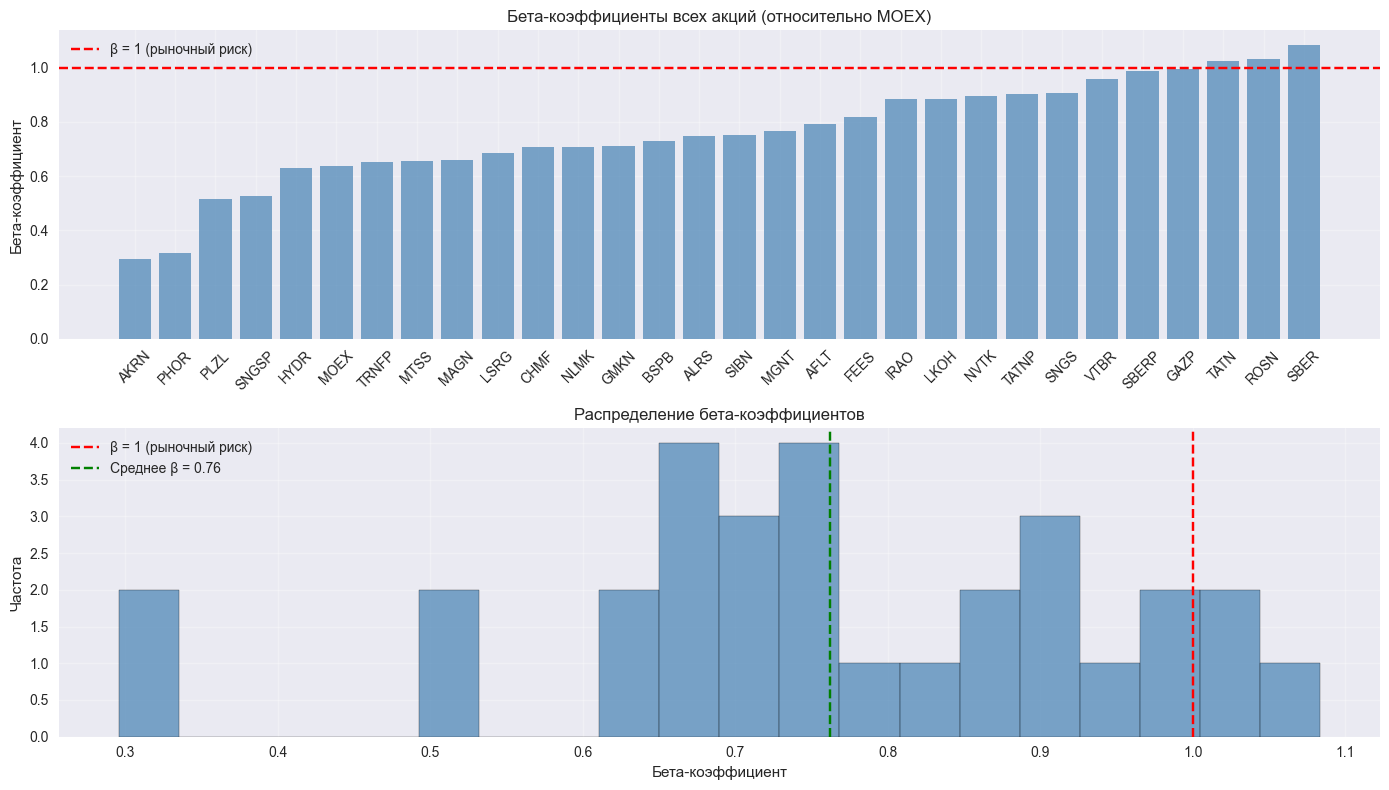

In [70]:
plt.figure(figsize=(14, 8))

betas_sorted = betas_result['betas'].sort_values()

plt.subplot(2, 1, 1)
bars = plt.bar(range(len(betas_sorted)), betas_sorted.values, color='steelblue', alpha=0.7)
plt.axhline(y=1, color='red', linestyle='--', label='β = 1 (рыночный риск)')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
plt.xticks(range(len(betas_sorted)), betas_sorted.index, rotation=45)
plt.ylabel('Бета-коэффициент')
plt.title('Бета-коэффициенты всех акций (относительно MOEX)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.hist(betas_result['betas'].values, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(x=1, color='red', linestyle='--', label='β = 1 (рыночный риск)')
plt.axvline(x=betas_result['betas'].mean(), color='green', linestyle='--', label=f'Среднее β = {betas_result["betas"].mean():.2f}')
plt.xlabel('Бета-коэффициент')
plt.ylabel('Частота')
plt.title('Распределение бета-коэффициентов')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Сравнение ковариационных матриц**

**Визуализация разности ковариационных матриц**

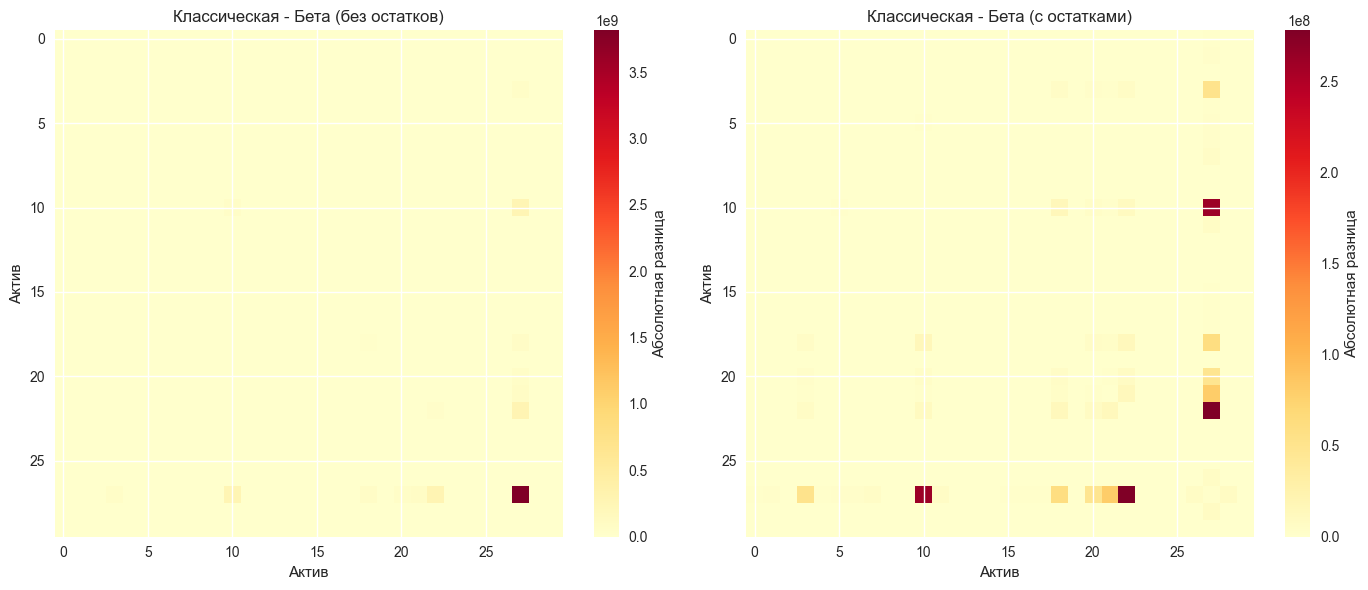

In [ ]:
cov_comparison = compare_covariance_methods(
    calculate_returns(load_imoex_data('data/imoex_prices.csv')),
    stoks_prices_df
)

diff_simple = np.abs(cov_comparison['classic'] - cov_comparison['beta_simple'])
diff_residuals = np.abs(cov_comparison['classic'] - cov_comparison['beta_residuals'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(diff_simple, cmap='YlOrRd', aspect='auto')
axes[0].set_title('Классическая - Бета (без остатков)')
axes[0].set_xlabel('Актив')
axes[0].set_ylabel('Актив')
plt.colorbar(im1, ax=axes[0], label='Абсолютная разница')

im2 = axes[1].imshow(diff_residuals, cmap='YlOrRd', aspect='auto')
axes[1].set_title('Классическая - Бета (с остатками)')
axes[1].set_xlabel('Актив')
axes[1].set_ylabel('Актив')
plt.colorbar(im2, ax=axes[1], label='Абсолютная разница')

plt.tight_layout()
plt.show()

**Выводы по задаче 13:**
- Бета-коэффициенты отражают чувствительность каждой акции к рыночным движениям
- Акции с β > 1 более волатильны рынка (агрессивные)
- Акции с β < 1 менее волатильны рынка (защитные)
- Бета-модель упрощает структуру ковариационной матрицы, предполагая, что все ковариации объясняются через рыночный риск
- Учет остаточных дисперсий (idiosyncratic risk) улучшает соответствие с классической ковариационной матрицей
- Средняя разница между классической и бета-матрицей с остатками обычно меньше, чем без остатков

#### 14 Эффективная граница на основе исторических β

In [ ]:
stock_tickers = [col for col in returns.columns if col != 'MOEX']
stock_returns = returns[stock_tickers]
mean_returns = stock_returns.mean().values

ef_returns_beta, ef_stds_beta = task_14_efficient_frontier_from_betas(
    imoex_returns_file='data/imoex_prices.csv',
    stock_returns_file='data/prices_moex_new.csv',
    n_points=50,
    include_residuals=True
)

**Визуализация эффективной границы на основе бета**

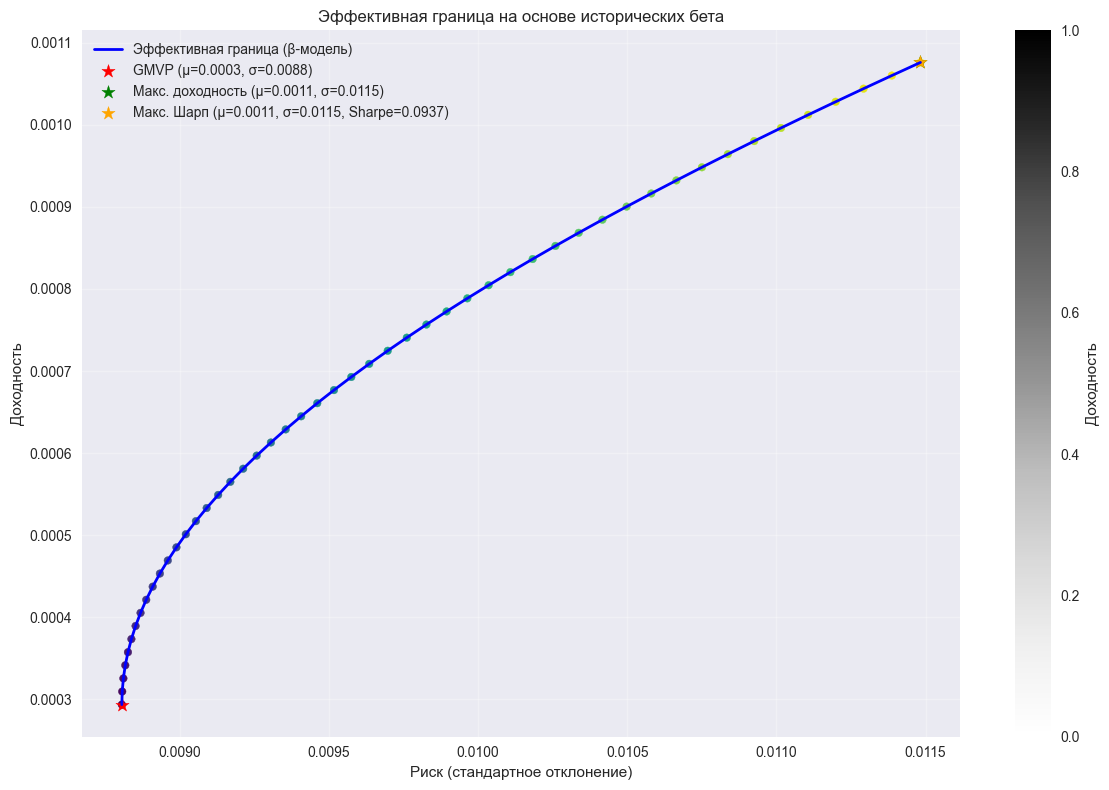

In [73]:
plt.figure(figsize=(12, 8))

plt.plot(ef_stds_beta, ef_returns_beta, 'b-', linewidth=2, label='Эффективная граница (β-модель)')
plt.scatter(ef_stds_beta, ef_returns_beta, c=ef_returns_beta, cmap='viridis', s=30)

plt.scatter(ef_stds_beta[0], ef_returns_beta[0], color='red', s=100, marker='*', 
            label=f'GMVP (μ={ef_returns_beta[0]:.4f}, σ={ef_stds_beta[0]:.4f})')

plt.scatter(ef_stds_beta[-1], ef_returns_beta[-1], color='green', s=100, marker='*', 
            label=f'Макс. доходность (μ={ef_returns_beta[-1]:.4f}, σ={ef_stds_beta[-1]:.4f})')

sharpe_ratios = ef_returns_beta / ef_stds_beta
max_sharpe_idx = np.argmax(sharpe_ratios)
plt.scatter(ef_stds_beta[max_sharpe_idx], ef_returns_beta[max_sharpe_idx], color='orange', s=100, marker='*',
            label=f'Макс. Шарп (μ={ef_returns_beta[max_sharpe_idx]:.4f}, σ={ef_stds_beta[max_sharpe_idx]:.4f}, Sharpe={sharpe_ratios[max_sharpe_idx]:.4f})')

plt.colorbar(label='Доходность')
plt.xlabel('Риск (стандартное отклонение)')
plt.ylabel('Доходность')
plt.title('Эффективная граница на основе исторических бета')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Выводы по задаче 14:**
- Эффективная граница на основе β-модель имеет классическую вогнутую форму
- β-модель обеспечивает упрощенную структуру ковариационной матрицы, что может привести к более стабильным портфельным весам
- Метод позволяет легко интерпретировать риск портфеля через рыночный фактор
- Поскольку β-коэффициенты более стабильны во времени, чем классическая ковариационная матрица, эффективная граница на основе β может быть более устойчивой

#### 15 Динамика эффективных границ на основе исторических β

In [ ]:
beta_frontiers, beta_stability = task_15_efficient_frontier_dynamics_betas(
    imoex_returns_file='data/imoex_prices.csv',
    stock_returns_file='data/prices_moex_new.csv',
    window_size='1Y',
    step_size='1Y',
    include_residuals=True,
    n_points=50
)

**Визуализация динамики эффективных границ на основе β**

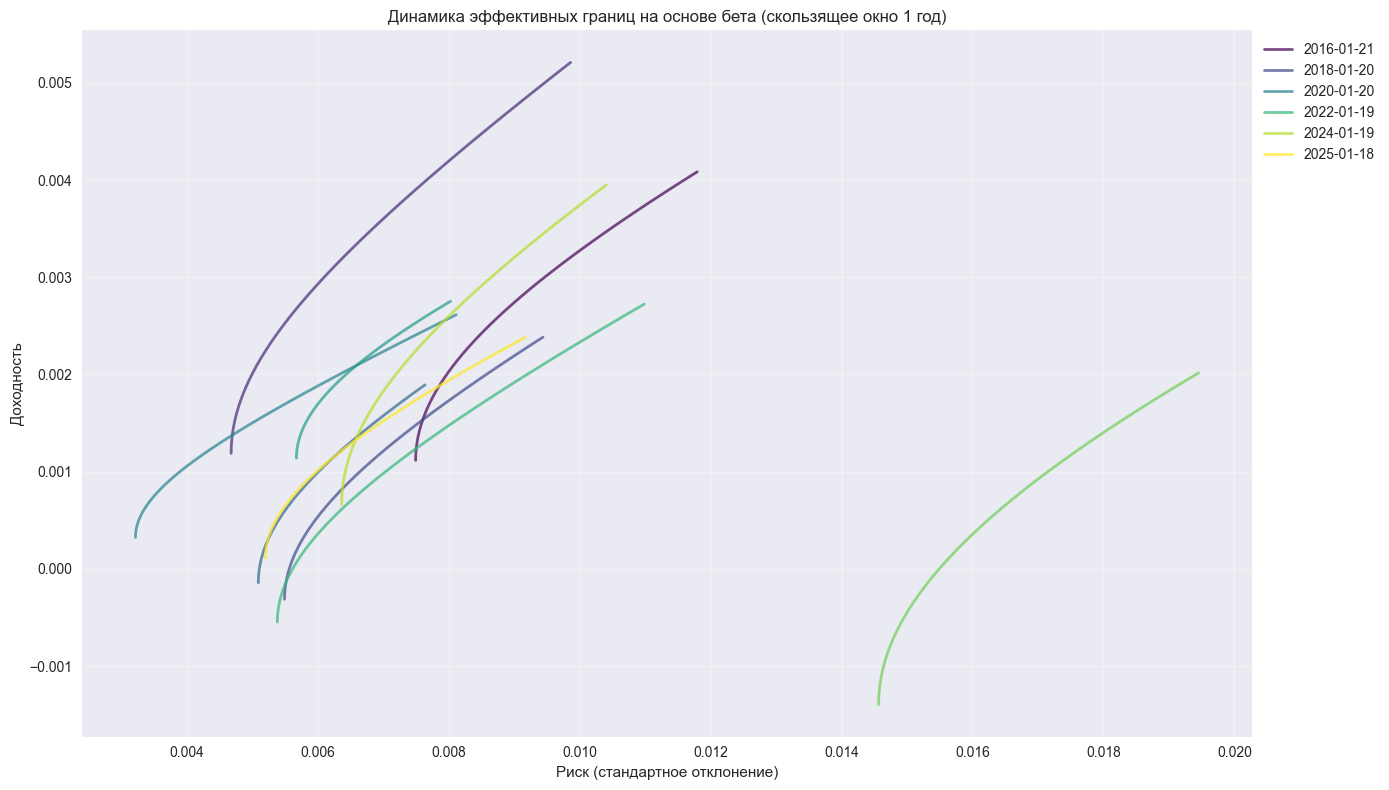

In [ ]:
plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(beta_frontiers)))

for i, (date, frontier) in enumerate(sorted(beta_frontiers.items())):
    label = date.strftime('%Y-%m-%d') if i % 2 == 0 or i == len(beta_frontiers) - 1 else None
    plt.plot(frontier['stds'], frontier['returns'], 
             color=colors[i], linewidth=2, alpha=0.7, label=label)

plt.xlabel('Риск (стандартное отклонение)')
plt.ylabel('Доходность')
plt.title('Динамика эффективных границ на основе бета (скользящее окно 1 год)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Динамика минимального риска и максимального Шарпа во времени (β-модель)**

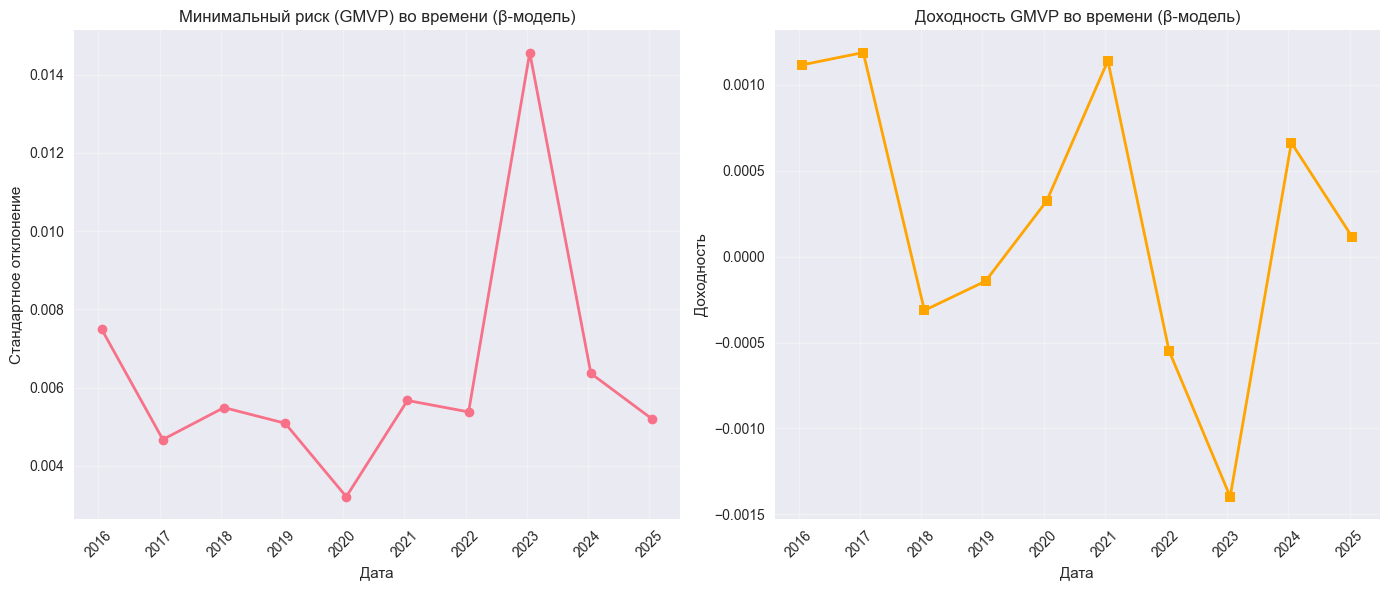

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(beta_stability.index, beta_stability['min_std'], marker='o', linewidth=2)
plt.title('Минимальный риск (GMVP) во времени (β-модель)')
plt.xlabel('Дата')
plt.ylabel('Стандартное отклонение')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(beta_stability.index, beta_stability['min_std_return'], marker='s', linewidth=2, color='orange')
plt.title('Доходность GMVP во времени (β-модель)')
plt.xlabel('Дата')
plt.ylabel('Доходность')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Динамика максимального Шарп-отношения во времени (β-модель)**

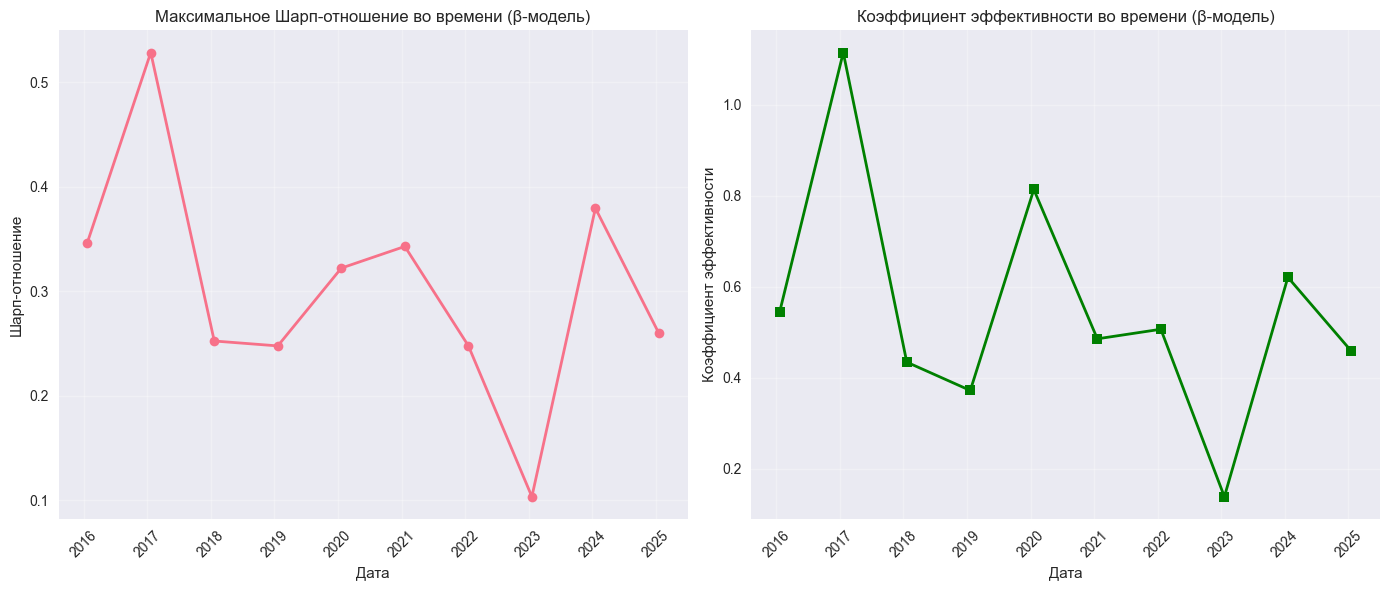

In [77]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(beta_stability.index, beta_stability['max_sharpe'], marker='o', linewidth=2)
plt.title('Максимальное Шарп-отношение во времени (β-модель)')
plt.xlabel('Дата')
plt.ylabel('Шарп-отношение')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(beta_stability.index, beta_stability['efficiency_ratio'], marker='s', linewidth=2, color='green')
plt.title('Коэффициент эффективности во времени (β-модель)')
plt.xlabel('Дата')
plt.ylabel('Коэффициент эффективности')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Выводы по задаче 15:**
- Эффективные границы на основе β-модели демонстрируют динамику во времени, но менее вариативны, чем классические границы
- Минимальный риск на основе β-модели более стабилен во времени
- Это подтверждает преимущество β-коэффициентов — они более стабильны и предсказуемы, чем полная ковариационная матрица
- Сравнение с классической моделью показывает, что β-модель может давать консервативные оценки риска
- Для долгосрочного портфельного управления β-модель может быть предпочтительнее из-за стабильности оценок

### 16-20. Скорректированные β и сравнение трех способов оценки covariance matrix

В этом разделе выполняются пункты 16-20 задания **в соответствии с уже выбранной в пункте 12 схемой**.

Что фиксируем из пункта 12:
- историческая схема - **скользящее окно длиной 1 год**;
- схема взвешивания - **равные веса наблюдений**;
- индекс для рыночной модели - **IMOEX**.

Для однооконных задач 16, 17 и 19 внутри этой схемы нужно взять одно конкретное годовое окно.  
Ниже используется последнее доступное годовое окно в выборке.

Фактически для расчетов 16, 17 и 19 используется окно:
- начало - **2025-01-03**
- конец - **2025-12-30**
- число общих торговых наблюдений после объединения акций с IMOEX - **250**

Сами сравнения:
- **Historical returns** - классическая историческая ковариационная матрица;
- **Historical betas** - ковариационная матрица single-index model на основе исторических β;
- **Adjusted betas** - та же single-index model, но с корректировкой  
  \[
  \beta_i^{adj} = 0.67 \cdot \beta_i^{hist} + 0.33 \cdot 1
  \]

Во всех трех случаях вектор ожидаемых доходностей берется из **исторических средних доходностей акций на том же окне**, чтобы сравнение было чистым и менялся только способ оценки риска.


In [78]:
def _resolve_existing_path(*candidates):
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"Файл не найден. Проверены пути: {candidates}")


In [79]:
imoex_path = _resolve_existing_path(
    "imoex_prices.csv",
    "data/imoex_prices.csv",
    "/mnt/data/imoex_prices.csv"
)

imoex_prices_df = load_market_index_data(imoex_path, index_name="IMOEX")
imoex_returns = calculate_market_returns(imoex_prices_df)

print("Файл индекса:", imoex_path)
print("Период по индексу:", imoex_prices_df.index.min().date(), "-", imoex_prices_df.index.max().date())
print("Число наблюдений по индексу:", len(imoex_prices_df))


Файл индекса: data/imoex_prices.csv
Период по индексу: 2015-01-05 - 2025-12-30
Число наблюдений по индексу: 2764


In [80]:
selected_beta_window = prepare_selected_beta_window(
    stock_returns=returns,
    market_returns=imoex_returns,
    market_column="IMOEX",
    window_size="1Y",
    selection_mode="latest"
)

print("Схема из пункта 12:")
print("- окно: rolling 1Y")
print("- веса: равные")
print("- индекс: IMOEX")
print()
print("Выбранное одно годовое окно для пунктов 16, 17 и 19:")
print("Начало окна:", selected_beta_window["window_start"].date())
print("Конец окна:", selected_beta_window["window_end"].date())
print("Число общих наблюдений:", selected_beta_window["window_size"])

stock_window = selected_beta_window["stock_returns"]
market_window = selected_beta_window["market_returns"]

print()
print("Размер матрицы доходностей акций:", stock_window.shape)
print("Длина ряда IMOEX:", len(market_window))


Схема из пункта 12:
- окно: rolling 1Y
- веса: равные
- индекс: IMOEX

Выбранное одно годовое окно для пунктов 16, 17 и 19:
Начало окна: 2025-01-03
Конец окна: 2025-12-30
Число общих наблюдений: 250

Размер матрицы доходностей акций: (250, 30)
Длина ряда IMOEX: 250


#### 16. Ковариационная матрица на основе скорректированных β

Сначала оцениваются исторические β по рыночной модели относительно **IMOEX**, затем они корректируются по формуле adjusted beta.  
После этого строится ковариационная матрица single-index model


Ниже считаем эту матрицу и смотрим, как изменились β после корректировки.


In [81]:
adjusted_beta_result = covariance_from_adjusted_betas(
    stock_returns=stock_window,
    market_returns=market_window,
    include_residuals=True,
    weight_raw=0.67,
    weight_market=0.33,
    market_beta=1.0
)

betas_compare_df = pd.DataFrame({
    "historical_beta": adjusted_beta_result["raw_betas"],
    "adjusted_beta": adjusted_beta_result["adjusted_betas"],
    "residual_variance": adjusted_beta_result["residual_variances"]
}).sort_values("historical_beta")

print("Размер covariance matrix:", adjusted_beta_result["cov_matrix"].shape)
print("Дисперсия рынка IMOEX:", round(adjusted_beta_result["market_variance"], 8))
display(betas_compare_df.head(10))
display(betas_compare_df.tail(10))


Размер covariance matrix: (30, 30)
Дисперсия рынка IMOEX: 0.00022226


,historical_beta,adjusted_beta,residual_variance
AKRN,0.210183,0.470823,0.000061
BSPB,0.302680,0.532795,0.000191
PHOR,0.323763,0.546921,0.000185
SNGSP,0.343307,0.560015,0.000223
TRNFP,0.397817,0.596538,0.000298
PLZL,0.422942,0.613371,0.000300
SIBN,0.432005,0.619443,0.000227
IRAO,0.478139,0.650353,0.000169
SBERP,0.490423,0.658583,0.000136
MTSS,0.495993,0.662315,0.000278


,historical_beta,adjusted_beta,residual_variance
CHMF,0.732969,0.821089,0.000354
GMKN,0.740862,0.826377,0.000422
TATN,0.744631,0.828903,0.000332
TATNP,0.753676,0.834963,0.000280
LSRG,0.761857,0.840444,0.000256
MAGN,0.783254,0.854780,0.000337
VTBR,0.795722,0.863134,0.000643
NLMK,0.820460,0.879708,0.000300
NVTK,0.937327,0.958009,0.000453
GAZP,0.989195,0.992761,0.000295


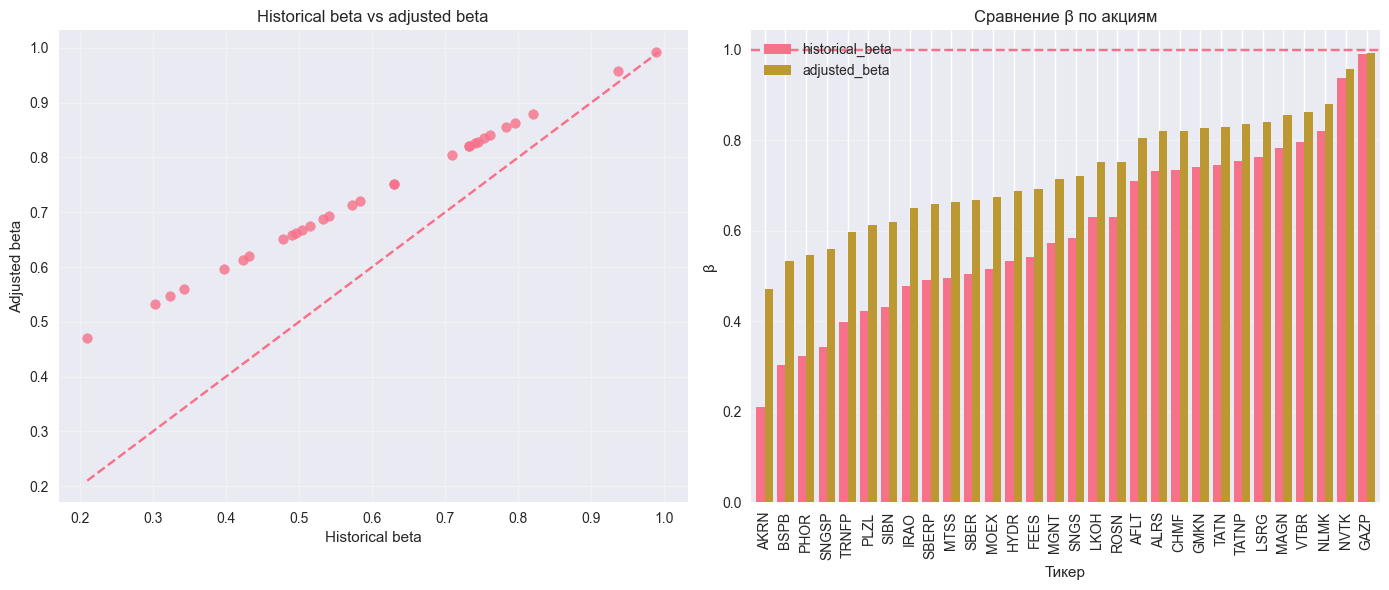

In [82]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(
    betas_compare_df["historical_beta"],
    betas_compare_df["adjusted_beta"],
    alpha=0.8
)
min_beta = min(betas_compare_df["historical_beta"].min(), betas_compare_df["adjusted_beta"].min())
max_beta = max(betas_compare_df["historical_beta"].max(), betas_compare_df["adjusted_beta"].max())
plt.plot([min_beta, max_beta], [min_beta, max_beta], linestyle="--")
plt.xlabel("Historical beta")
plt.ylabel("Adjusted beta")
plt.title("Historical beta vs adjusted beta")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
bars = betas_compare_df[["historical_beta", "adjusted_beta"]].plot(
    kind="bar",
    ax=plt.gca(),
    width=0.8
)
plt.axhline(1.0, linestyle="--")
plt.title("Сравнение β по акциям")
plt.xlabel("Тикер")
plt.ylabel("β")
plt.xticks(rotation=90)
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


#### 17. Эффективная граница на основе скорректированных β

Теперь используем рассчитанную covariance matrix из adjusted beta как вход для optimizer и строим эффективную границу на том же самом выбранном окне.


,portfolio_return,portfolio_std
0,-0.000001,0.008722
1,0.000045,0.008724
2,0.000090,0.008728
3,0.000136,0.008736
4,0.000181,0.008747


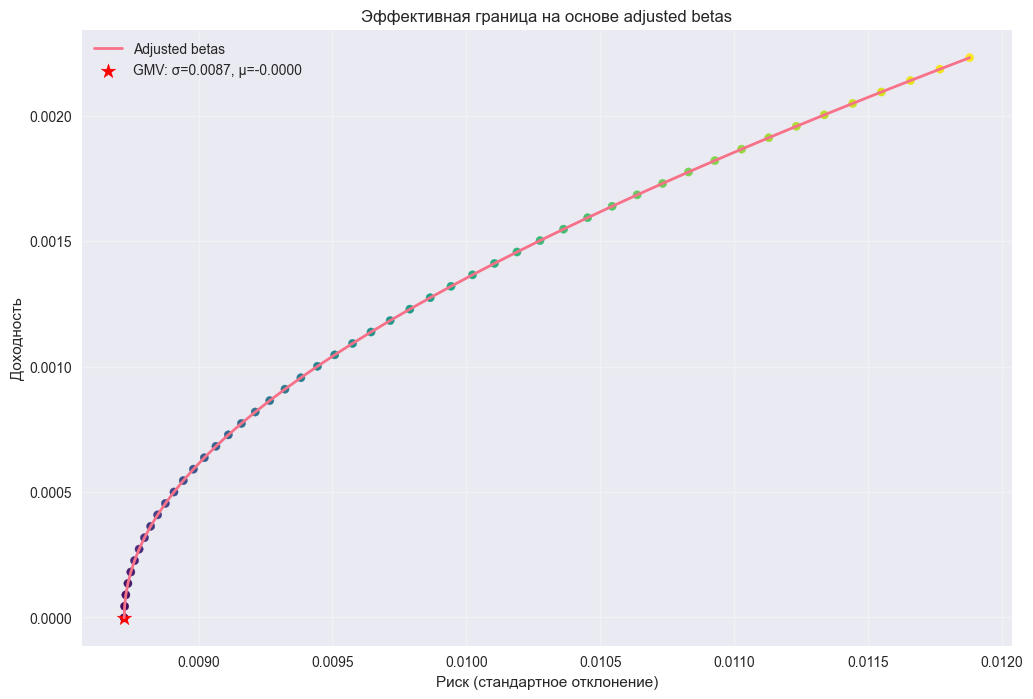

In [83]:
mean_returns_selected = stock_window.mean().values

ef_returns_adjusted, ef_stds_adjusted = efficient_frontier_from_adjusted_betas(
    cov_matrix=adjusted_beta_result["cov_matrix"],
    mean_returns=mean_returns_selected,
    n_points=50
)

adjusted_frontier_df = pd.DataFrame({
    "portfolio_return": ef_returns_adjusted,
    "portfolio_std": ef_stds_adjusted
})

display(adjusted_frontier_df.head())

plt.figure(figsize=(12, 8))
plt.plot(ef_stds_adjusted, ef_returns_adjusted, linewidth=2, label="Adjusted betas")
plt.scatter(ef_stds_adjusted, ef_returns_adjusted, c=ef_returns_adjusted, cmap="viridis", s=35)
plt.scatter(
    ef_stds_adjusted[0], ef_returns_adjusted[0],
    s=120, marker="*", color="red",
    label=f"GMV: σ={ef_stds_adjusted[0]:.4f}, μ={ef_returns_adjusted[0]:.4f}"
)
plt.xlabel("Риск (стандартное отклонение)")
plt.ylabel("Доходность")
plt.title("Эффективная граница на основе adjusted betas")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


#### 18. Динамика эффективной границы на основе скорректированных β

Для динамики повторяем расчет на последовательности годовых rolling windows с шагом 1 год.  
**10 окон** всего.


Получено окон: 10


,min_std,min_std_return,max_return,max_return_std,max_sharpe,...,frontier_range,min_std_change,min_std_return_change,max_return_change,max_sharpe_change
date,,,,,,,,,,,
2016-01-21,0.009309,0.001105,0.004098,0.012891,0.317899,...,0.002993,NaN,NaN,NaN,NaN
2017-01-20,0.005868,0.001017,0.005143,0.010447,0.492325,...,0.004126,-0.003441,-0.000088,0.001045,0.174426
2018-01-20,0.006632,-0.000307,0.002456,0.010189,0.241062,...,0.002763,0.000764,-0.001324,-0.002687,-0.251263
2019-01-20,0.006807,-0.000188,0.001893,0.008945,0.211616,...,0.002081,0.000175,0.000118,-0.000563,-0.029447
2020-01-20,0.004308,0.000237,0.002614,0.008676,0.301365,...,0.002377,-0.002499,0.000426,0.000722,0.089749
2021-01-19,0.007885,0.001509,0.002751,0.008936,0.307845,...,0.001242,0.003577,0.001271,0.000137,0.006480
2022-01-19,0.007290,-0.000629,0.002736,0.012036,0.227288,...,0.003365,-0.000596,-0.002138,-0.000015,-0.080556
2023-01-19,0.020679,-0.001438,0.001881,0.024083,0.078103,...,0.003319,0.013389,-0.000809,-0.000855,-0.149186
2024-01-19,0.007282,0.000791,0.003970,0.010610,0.374191,...,0.003179,-0.013397,0.002229,0.002089,0.296088


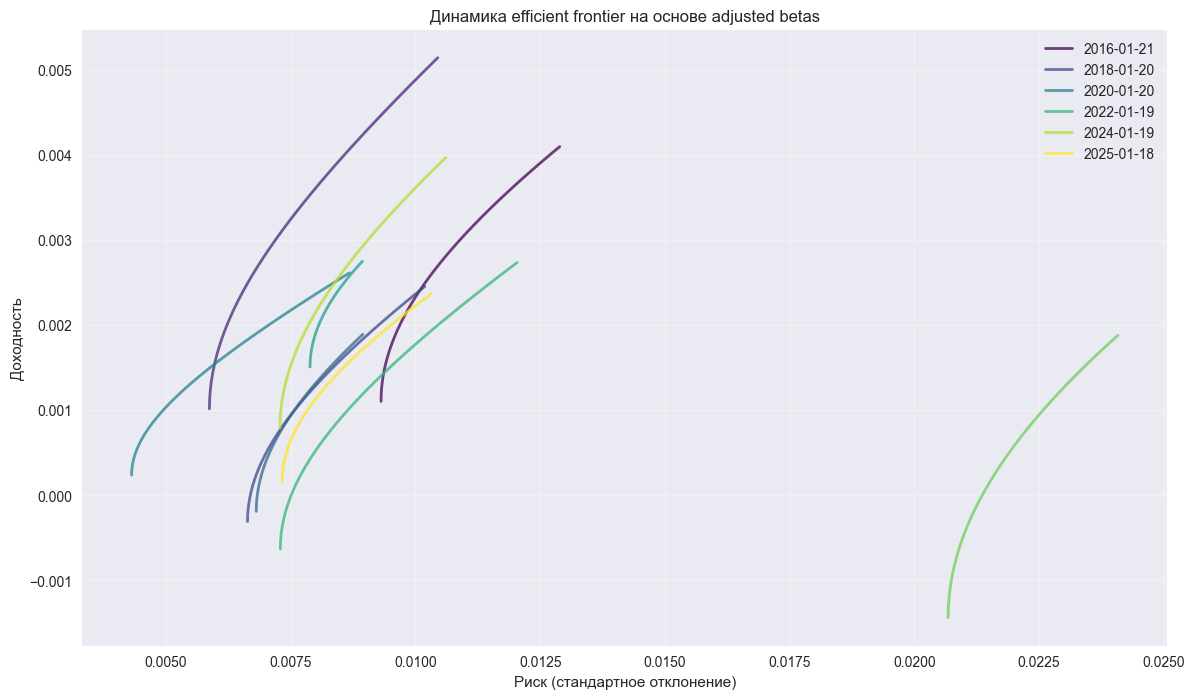

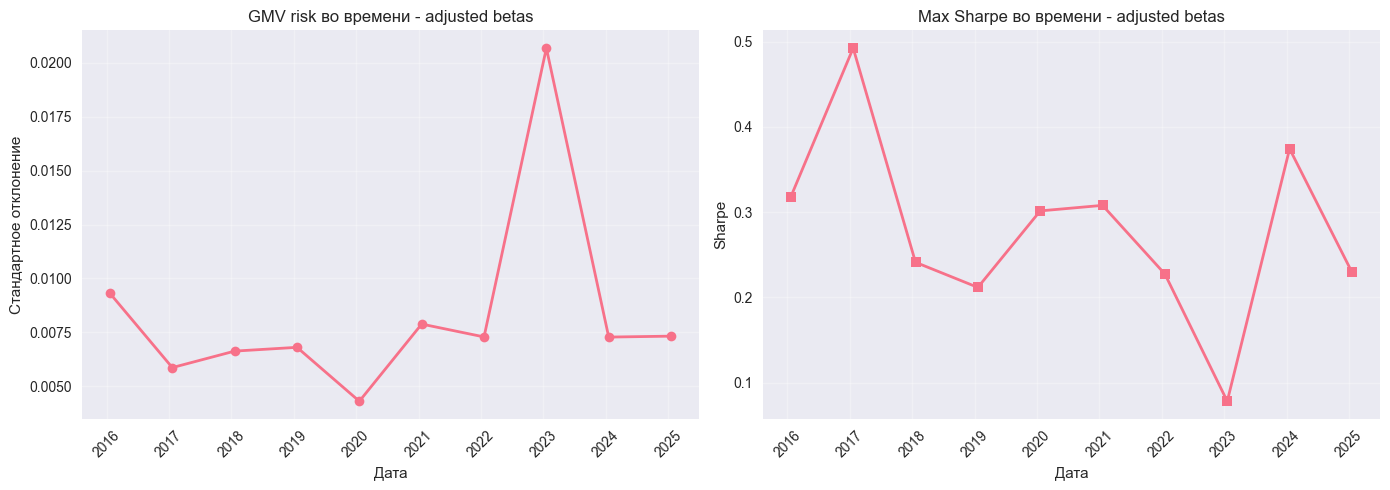

In [84]:
adjusted_frontiers_time, adjusted_stability = efficient_frontier_dynamics_adjusted_betas(
    stock_returns=returns,
    market_returns=imoex_returns,
    market_column="IMOEX",
    window_size="1Y",
    step_size="1Y",
    include_residuals=True,
    n_points=40
)

print("Получено окон:", len(adjusted_frontiers_time))
display(adjusted_stability)

plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(adjusted_frontiers_time)))

for i, (date, frontier) in enumerate(sorted(adjusted_frontiers_time.items())):
    label = date.strftime("%Y-%m-%d") if i % 2 == 0 or i == len(adjusted_frontiers_time) - 1 else None
    plt.plot(frontier["stds"], frontier["returns"], color=colors[i], linewidth=2, alpha=0.75, label=label)

plt.xlabel("Риск (стандартное отклонение)")
plt.ylabel("Доходность")
plt.title("Динамика efficient frontier на основе adjusted betas")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(adjusted_stability.index, adjusted_stability["min_std"], marker="o", linewidth=2)
plt.title("GMV risk во времени - adjusted betas")
plt.xlabel("Дата")
plt.ylabel("Стандартное отклонение")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(adjusted_stability.index, adjusted_stability["max_sharpe"], marker="s", linewidth=2)
plt.title("Max Sharpe во времени - adjusted betas")
plt.xlabel("Дата")
plt.ylabel("Sharpe")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


#### 19. Сравнение трех подходов на одном выбранном окне

Ниже сравниваются три метода **на одном и том же окне**:
- historical returns,
- historical betas,
- adjusted betas.

Такое сравнение корректно, потому что:
- выборка одна и та же;
- средние доходности акций одни и те же;
- отличается только способ оценки covariance matrix.


,gmv_return,gmv_std,max_return,max_return_std,max_sharpe,max_sharpe_return,max_sharpe_std,frontier_range,efficiency_ratio
method,,,,,,,,,
Historical betas,-0.000056,0.006038,0.002231,0.010265,0.217345,0.002231,0.010265,0.002287,0.369489
Historical returns,-0.000246,0.006344,0.002231,0.009458,0.235899,0.002231,0.009458,0.002478,0.351675
Adjusted betas,-0.000001,0.008722,0.002231,0.011879,0.187819,0.002231,0.011879,0.002232,0.255800


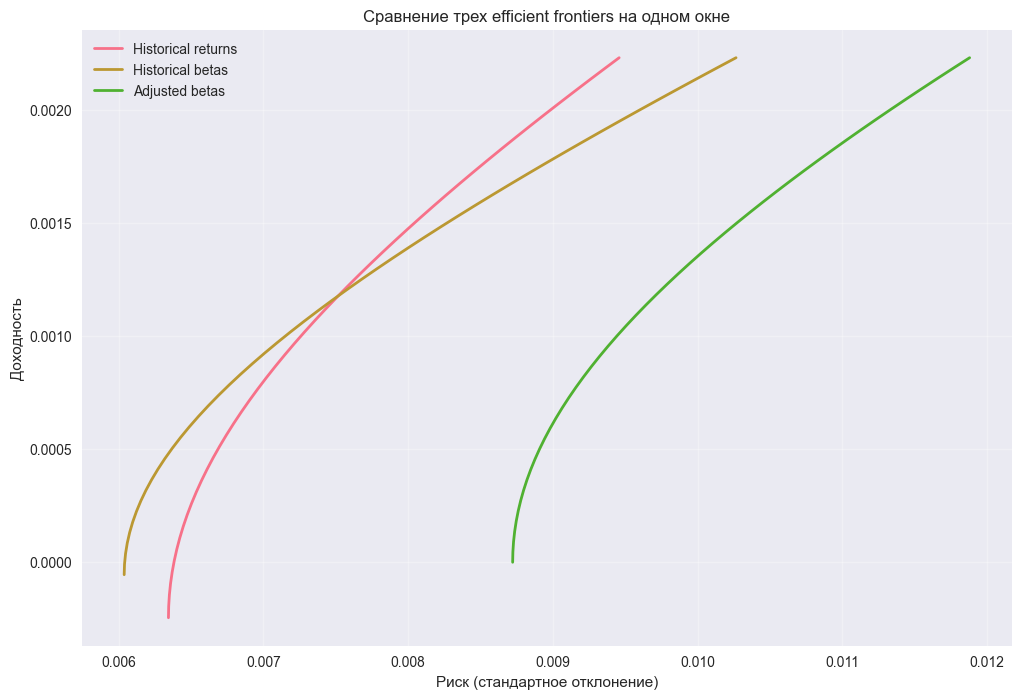

In [85]:
selected_window_comparison = compare_three_methods_on_selected_window(
    stock_returns=stock_window,
    market_returns=market_window,
    include_residuals=True,
    n_points=50
)

comparison_selected_df = selected_window_comparison["summary_table"].sort_values("gmv_std")
display(comparison_selected_df)

plt.figure(figsize=(12, 8))

for method_name, frontier in selected_window_comparison["frontiers"].items():
    plt.plot(frontier["stds"], frontier["returns"], linewidth=2, label=method_name)

plt.xlabel("Риск (стандартное отклонение)")
plt.ylabel("Доходность")
plt.title("Сравнение трех efficient frontiers на одном окне")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


По выбранному окну видно следующее.

- **Historical betas** дали самый низкий риск GMV-портфеля: примерно **0.006038**.
- **Historical returns** оказались очень близки по GMV-риску: примерно **0.006344**.
- **Adjusted betas** дали более консервативную оценку риска: GMV-риск вырос до **0.008722**.
- По максимальному Sharpe лучшим в этом окне оказался метод **Historical returns** с уровнем около **0.235899**, а weakest из трех оказался **Adjusted betas** с уровнем около **0.187819**.

Экономическая интерпретация такая:
historical covariance matrix сильнее отражает фактическую совместную динамику бумаг на данном окне, historical beta выделяет систематическую компоненту риска через рынок, а adjusted beta дополнительно сглаживает исторические оценки β, притягивая их к единице. Поэтому adjusted beta обычно делает оценки менее чувствительными к шуму конкретного окна, но при этом нередко дает более осторожную, менее агрессивную frontier.


#### 20. Сравнение трех подходов на разных окнах

Теперь то же самое сравнение проводится не для одного окна, а для всей последовательности rolling windows.  
Это позволяет посмотреть, насколько результаты устойчивы во времени и какой метод в среднем дает более рискованную или более эффективную frontier.


,avg_gmv_std,std_gmv_std,avg_max_sharpe,std_max_sharpe,avg_efficiency_ratio,avg_frontier_range
method,,,,,,
Historical betas,0.006299,0.003094,0.304208,0.112488,0.550958,0.002802
Historical returns,0.006527,0.002918,0.303506,0.101712,0.523780,0.002669
Adjusted betas,0.008339,0.004525,0.278118,0.109986,0.425530,0.002766


,date,method,gmv_return,gmv_std,max_return,...,max_sharpe,max_sharpe_return,max_sharpe_std,frontier_range,efficiency_ratio
0,2016-01-21,Adjusted betas,0.001105,0.009309,0.004098,...,0.317899,0.004098,0.012891,0.002993,0.440217
1,2016-01-21,Historical betas,0.001058,0.007471,0.004098,...,0.346236,0.004098,0.011836,0.003040,0.548532
2,2016-01-21,Historical returns,0.001008,0.008014,0.004098,...,0.328733,0.004098,0.012466,0.003090,0.511358
3,2017-01-20,Adjusted betas,0.001017,0.005868,0.005143,...,0.492325,0.005143,0.010447,0.004126,0.876457
4,2017-01-20,Historical betas,0.001068,0.004557,0.005143,...,0.530472,0.005143,0.009695,0.004075,1.128648
5,2017-01-20,Historical returns,0.001179,0.004755,0.005143,...,0.495084,0.004733,0.009560,0.003964,1.081644
6,2018-01-20,Adjusted betas,-0.000307,0.006632,0.002456,...,0.241062,0.002456,0.010189,0.002763,0.370328
7,2018-01-20,Historical betas,-0.000301,0.005497,0.002456,...,0.256647,0.002456,0.009570,0.002757,0.446813
8,2018-01-20,Historical returns,-0.000152,0.005534,0.002456,...,0.265065,0.002456,0.009266,0.002608,0.443793
9,2019-01-20,Adjusted betas,-0.000188,0.006807,0.001893,...,0.211616,0.001893,0.008945,0.002081,0.278067


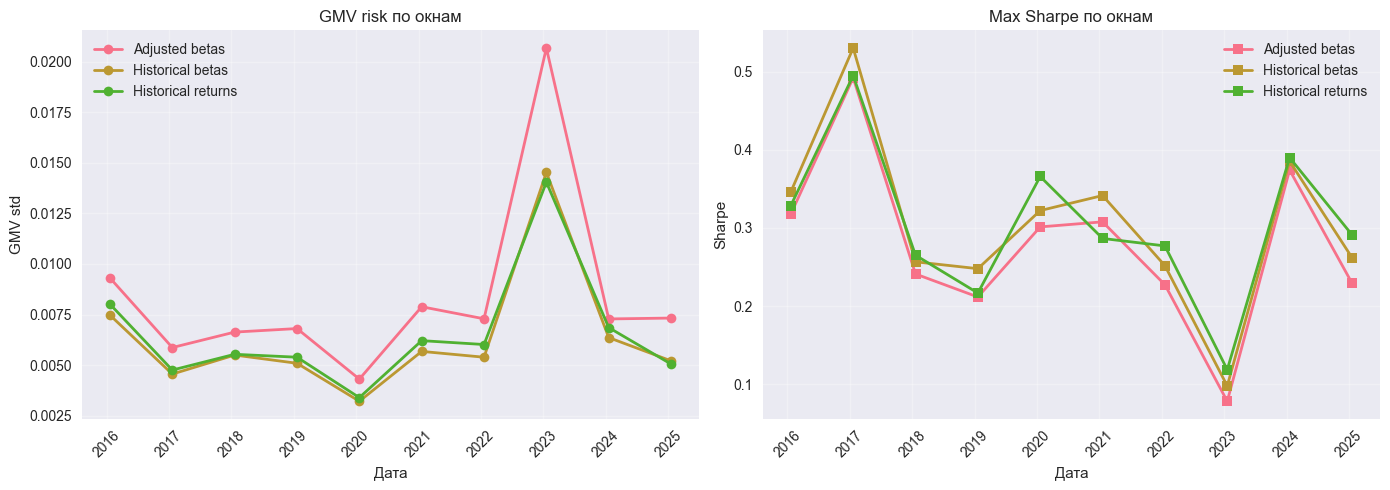

In [86]:
comparison_over_time = compare_three_methods_over_time(
    stock_returns=returns,
    market_returns=imoex_returns,
    market_column="IMOEX",
    window_size="1Y",
    step_size="1Y",
    include_residuals=True,
    n_points=30
)

comparison_time_summary = comparison_over_time["summary_by_method"].sort_values("avg_gmv_std")
comparison_time_metrics = comparison_over_time["metrics_table"]

display(comparison_time_summary)
display(comparison_time_metrics.head(12))

pivot_gmv = comparison_time_metrics.pivot(index="date", columns="method", values="gmv_std")
pivot_sharpe = comparison_time_metrics.pivot(index="date", columns="method", values="max_sharpe")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for col in pivot_gmv.columns:
    plt.plot(pivot_gmv.index, pivot_gmv[col], marker="o", linewidth=2, label=col)
plt.title("GMV risk по окнам")
plt.xlabel("Дата")
plt.ylabel("GMV std")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1, 2, 2)
for col in pivot_sharpe.columns:
    plt.plot(pivot_sharpe.index, pivot_sharpe[col], marker="s", linewidth=2, label=col)
plt.title("Max Sharpe по окнам")
plt.xlabel("Дата")
plt.ylabel("Sharpe")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()


Итог по пункту 20 

По средним значениям за все окна:
- **Historical betas** дали самый низкий средний GMV-риск - около **0.006299**;
- **Historical returns** очень близки - около **0.006527**;
- **Adjusted betas** оказались самыми консервативными - около **0.008339**.

По среднему максимальному Sharpe:
- **Historical betas** - около **0.304208**;
- **Historical returns** - около **0.303506**;
- **Adjusted betas** - около **0.278118**.

Значит, adjusted beta в среднем действительно ведет себя как более сглаженный и осторожный способ оценки риска.  
Historical beta и classical historical covariance matrix дают более близкие друг к другу результаты, причем в среднем historical beta немного выигрывает по GMV-риску.

